# ET0737 Machine Learning & AI — Mini Project
## Diabetes Risk Prediction from the CDC BRFSS 2015 Health Survey

**School of EEE, Singapore Polytechnic — AY26/27 S1**

**Dataset:** CDC *Behavioral Risk Factor Surveillance System (BRFSS) 2015*
— 441,456 US adults surveyed by telephone.
Source (raw): https://www.cdc.gov/brfss/annual_data/annual_2015.html
— Kaggle mirror: https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system

We use `data/processed/diabetes_2015_clean.csv` — the tidy 240,184 × 34 table produced by
our companion notebook **`01_Diabetes_2015_Cleaning.ipynb`**.

---
### What this notebook does (the standard ML workflow)
1. **Load & understand** the cleaned data and *justify why each characteristic was kept*.
2. **Explore (EDA)** — class balance, distributions, and risk-factor relationships with Matplotlib/Seaborn.
3. **Preprocess** — feature engineering, one-hot encoding, scaling, and a leakage-safe **train / validation / test** split.
4. **Train & tune six models** — Logistic Regression, Random Forest, SVM (RBF), a **Neural Network (MLP)** and XGBoost, plus a **stacking ensemble** that combines our two strongest learners (**SVM + XGBoost**) under a **Logistic Regression meta-learner**.
5. **Evaluate & compare** — Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, and an overfitting check with 5-fold cross-validation.
6. **Predict** on new patients + an **interactive risk calculator** (ipywidgets).
7. **Business insights**, a **Responsible-GenAI** reflection, and a **deployment export** used by the companion clinic web app.

> **Problem type:** binary **classification**.
> **Target `Diabetes`** = 1 if the respondent is *pre-diabetic or diabetic* (stage 1 or 2), else 0.
> This "at-risk screening" framing is the clinically useful question — *who should be
> referred for a blood-glucose test?* — and it is the standard framing for this dataset.

## 1 · Setup & Load the Cleaned Data

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")   # silence loky's CPU-count probe on Win11

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Parallelism budget: this machine has 8 cores but limited free RAM. We parallelise at
# exactly ONE level -- the cross-validation search -- and keep every estimator
# single-threaded (n_jobs=1). This avoids nested worker pools that would each copy the
# 144k-row training set and exhaust memory (the classic "kernel died" failure).
N_JOBS = 4

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
print("Libraries loaded. scikit-learn + XGBoost are the core ML toolkit for this project.")
print(f"Parallelism capped at N_JOBS={N_JOBS} (one level only) to stay within RAM.")

Libraries loaded. scikit-learn + XGBoost are the core ML toolkit for this project.
Parallelism capped at N_JOBS=4 (one level only) to stay within RAM.


In [2]:
df = pd.read_csv("../data/processed/diabetes_2015_clean.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 240,184 rows x 34 columns


,DiabetesStage,HighBP,HighChol,CholCheck,BMI,BMICategory,Smoker,SmokerStatus,Stroke,HeartDiseaseorAttack,...,DiffWalk,Sex,Age,AgeYears,Race,MaritalStatus,Education,Income,Employment,CheckupTime
0,0,1,1,1,40.18,4,1,1,0,0,...,1,0,9,63,1,1,4,3,8,1
1,0,0,0,0,25.09,3,1,3,0,0,...,0,0,7,52,1,2,6,1,3,4
2,0,1,1,1,28.19,3,0,0,0,0,...,1,0,9,63,1,1,4,8,8,1
3,0,1,0,1,26.52,3,0,0,0,0,...,0,0,11,73,1,3,3,6,2,1
4,0,1,1,1,23.89,2,0,0,0,0,...,0,0,11,70,7,3,5,4,7,1


In [3]:
# Structure + basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240184 entries, 0 to 240183
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   DiabetesStage         240184 non-null  int64  
 1   HighBP                240184 non-null  int64  
 2   HighChol              240184 non-null  int64  
 3   CholCheck             240184 non-null  int64  
 4   BMI                   240184 non-null  float64
 5   BMICategory           240184 non-null  int64  
 6   Smoker                240184 non-null  int64  
 7   SmokerStatus          240184 non-null  int64  
 8   Stroke                240184 non-null  int64  
 9   HeartDiseaseorAttack  240184 non-null  int64  
 10  KidneyDisease         240184 non-null  int64  
 11  COPD                  240184 non-null  int64  
 12  Arthritis             240184 non-null  int64  
 13  Depression            240184 non-null  int64  
 14  PhysActivity          240184 non-null  int64  
 15  

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
DiabetesStage,240184.0,0.29,0.70,0.00,0.00,0.00,0.00,2.00
HighBP,240184.0,0.43,0.49,0.00,0.00,0.00,1.00,1.00
HighChol,240184.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
CholCheck,240184.0,0.96,0.19,0.00,1.00,1.00,1.00,1.00
BMI,240184.0,28.28,6.10,12.02,24.14,27.34,31.25,69.94
BMICategory,240184.0,2.99,0.81,1.00,2.00,3.00,4.00,4.00
Smoker,240184.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
SmokerStatus,240184.0,0.67,0.93,0.00,0.00,0.00,1.00,3.00
Stroke,240184.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00
HeartDiseaseorAttack,240184.0,0.09,0.29,0.00,0.00,0.00,0.00,1.00


## 2 · Why We Kept These Characteristics (Feature Justification)

The raw BRFSS survey has **330 columns**. Our cleaning notebook deliberately kept only
**33 predictors + the target**. Every kept characteristic is an *established, medically
plausible correlate of type-2 diabetes* — this is **domain-driven feature selection**,
which beats blindly throwing 330 noisy survey codes at a model (that would invite
over-fitting and hurt interpretability). We reject variables that (a) are survey
admin/weighting fields, (b) belong to unrelated modules (cancer, HIV, caregiving), or
(c) would **leak the target** (e.g. *age at diabetes diagnosis*, *insulin use*, *blood-sugar
test result* — those are only recorded **because** the person already has diabetes).

| # | Feature | Type | Why it predicts diabetes |
|---|---------|------|--------------------------|
| 1 | **BMI** | continuous | Excess body fat is the single biggest modifiable driver of insulin resistance. |
| 2 | **AgeYears** | continuous | Risk rises steeply with age as β-cell function declines. |
| 3 | **HighBP** | binary | Hypertension clusters with diabetes in metabolic syndrome. |
| 4 | **HighChol / CholCheck** | binary | Dyslipidaemia co-occurs with insulin resistance. |
| 5 | **GenHlth** | ordinal 1–5 | Self-rated health is a strong general morbidity proxy. |
| 6 | **DiffWalk / PhysHlth / MentHlth** | mixed | Functional limitation & poor health-days track chronic disease burden. |
| 7 | **HeartDiseaseorAttack / Stroke / KidneyDisease / COPD / Arthritis** | binary | Comorbidities that share risk factors with (or result from) diabetes. |
| 8 | **Smoker / SmokerStatus** | binary/ordinal | Smoking raises type-2 diabetes risk. |
| 9 | **PhysActivity / PhysActivityLevel** | binary/ordinal | Inactivity worsens glucose control. |
| 10 | **Fruits / Veggies / HvyAlcoholConsump** | binary | Diet quality & heavy drinking affect metabolic risk. |
| 11 | **Sex** | binary | Prevalence differs by sex. |
| 12 | **Income / Education / Employment / MaritalStatus** | ordinal/nominal | Socio-economic status shapes diet, stress & healthcare access. |
| 13 | **AnyHealthcare / NoDocbcCost / CheckupTime** | binary/ordinal | Healthcare access affects diagnosis & management. |
| 14 | **Race** | nominal | Prevalence varies across ethnic groups (must be used carefully — see Responsible-AI note). |

**Redundancy we will remove in §4:** the dataset ships **four** near-duplicate pairs, each
a finer- and coarser-grained copy of the same signal: `BMI` vs `BMICategory` (band),
`AgeYears` vs `Age` (5-year band), `Smoker` (binary) vs `SmokerStatus` (ordinal), and
`PhysActivity` (binary) vs `PhysActivityLevel` (ordinal). Keeping both members of a pair is
multicollinear and adds no information, so we keep exactly one of each: the **continuous**
`BMI` / `AgeYears` (dropping the bands), and the **binary** `Smoker` / `PhysActivity`
(dropping the ordinal recodes). We keep the binaries rather than the ordinals because they
correlate at least as strongly with the target *and*, unlike an ordinal passed through
un-encoded, they impose no unverified linear spacing on the linear models — giving cleaner,
more stable logistic-regression coefficients.

In [5]:
# Data-quality gate: the cleaning notebook already dropped all Don't-know/Refused codes,
# so we confirm there are no missing values and no exact duplicate rows to worry about.
print("Missing values per column (should all be 0):")
print(df.isna().sum().sum(), "total missing cells")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column (should all be 0):
0 total missing cells
Duplicate rows: 79


## 3 · Exploratory Data Analysis (EDA)

Before modelling we *look* at the data — the fastest way to catch imbalance, skew, and
whether the features actually relate to the target.

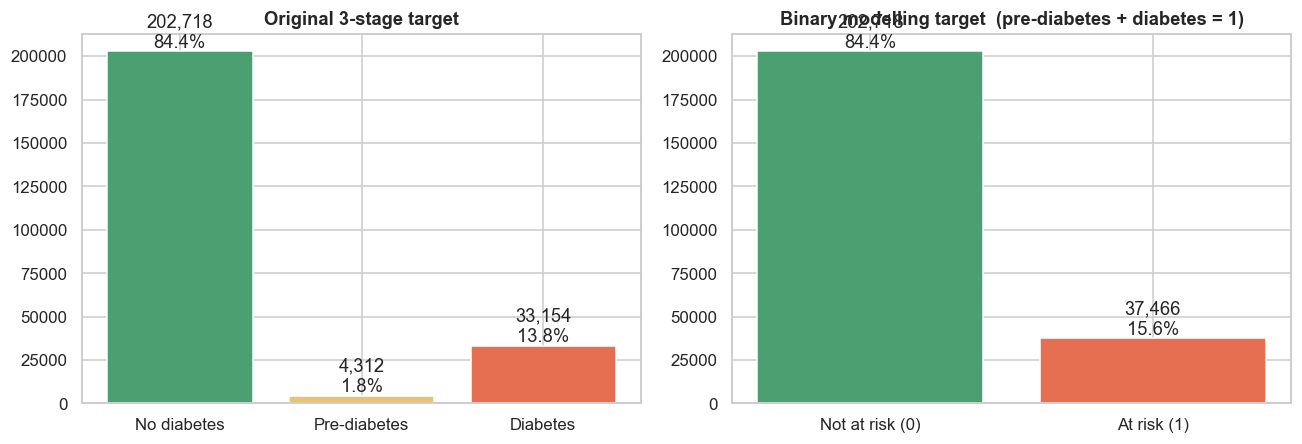

Positive (at-risk) rate: 15.6%  ->  this is an IMBALANCED problem.
=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,
   and use class_weight='balanced' so the minority class is not ignored.


In [6]:
# --- Build the binary target: at-risk (pre-diabetes OR diabetes) = 1 ---
labels3 = {0: "No diabetes", 1: "Pre-diabetes", 2: "Diabetes"}
df["Diabetes"] = (df["DiabetesStage"] >= 1).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = df["DiabetesStage"].value_counts().sort_index()
ax[0].bar([labels3[i] for i in sc.index], sc.values, color=["#4C9F70", "#E9C46A", "#E76F51"])
ax[0].set_title("Original 3-stage target")
for i, v in enumerate(sc.values):
    ax[0].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")

bc = df["Diabetes"].value_counts().sort_index()
ax[1].bar(["Not at risk (0)", "At risk (1)"], bc.values, color=["#4C9F70", "#E76F51"])
ax[1].set_title("Binary modelling target  (pre-diabetes + diabetes = 1)")
for i, v in enumerate(bc.values):
    ax[1].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive (at-risk) rate: {df['Diabetes'].mean():.1%}  ->  this is an IMBALANCED problem.")
print("=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,")
print("   and use class_weight='balanced' so the minority class is not ignored.")

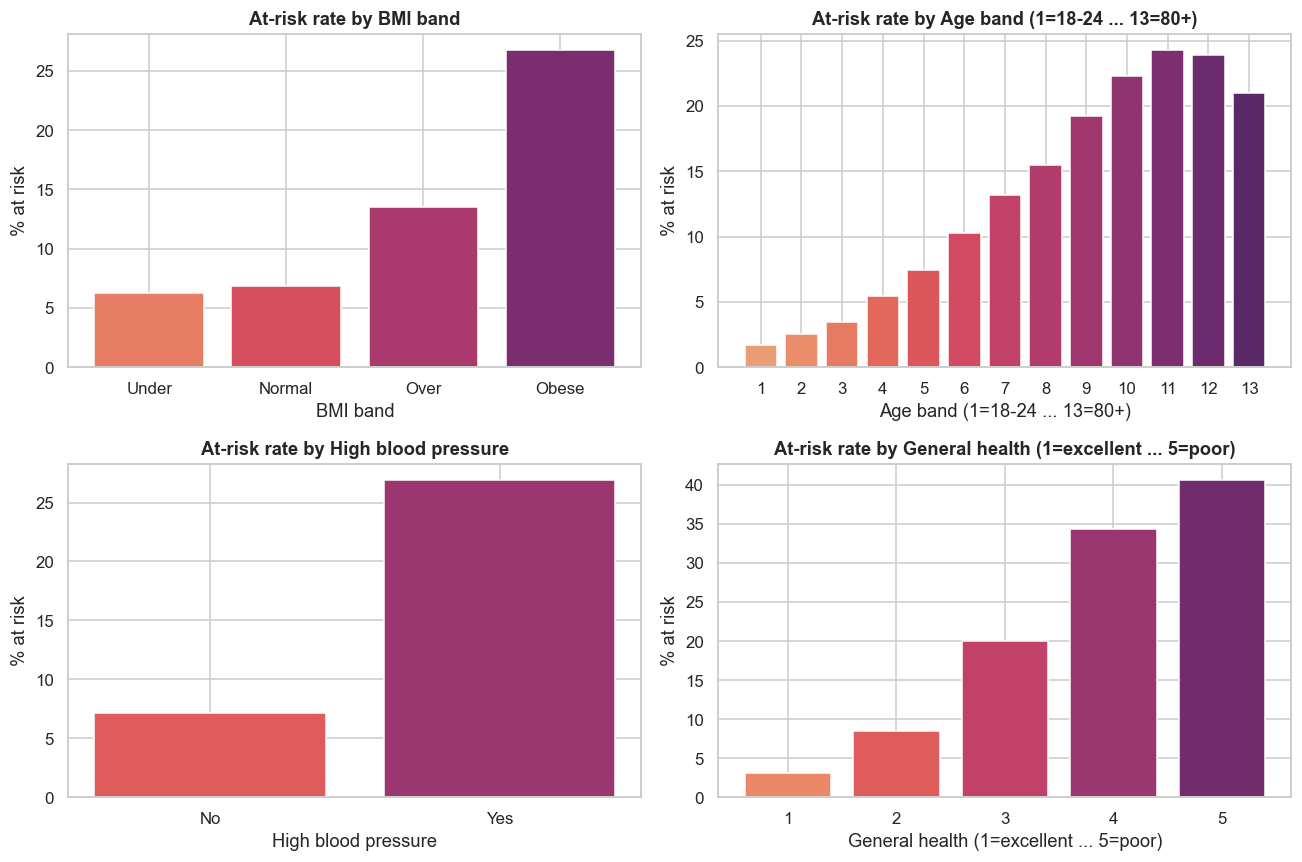

In [7]:
# Prevalence of diabetes/pre-diabetes across key risk factors — face-validity check
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
def prevalence_plot(ax, col, xlabel, xticklabels=None):
    p = df.groupby(col)["Diabetes"].mean() * 100
    ax.bar(p.index.astype(str), p.values, color=sns.color_palette("flare", len(p)))
    ax.set_title(f"At-risk rate by {xlabel}")
    ax.set_ylabel("% at risk"); ax.set_xlabel(xlabel)
    if xticklabels: ax.set_xticklabels(xticklabels, rotation=0)

prevalence_plot(axes[0,0], "BMICategory", "BMI band", ["Under", "Normal", "Over", "Obese"])
prevalence_plot(axes[0,1], "Age", "Age band (1=18-24 ... 13=80+)")
prevalence_plot(axes[1,0], "HighBP", "High blood pressure", ["No", "Yes"])
prevalence_plot(axes[1,1], "GenHlth", "General health (1=excellent ... 5=poor)")
plt.tight_layout(); plt.show()

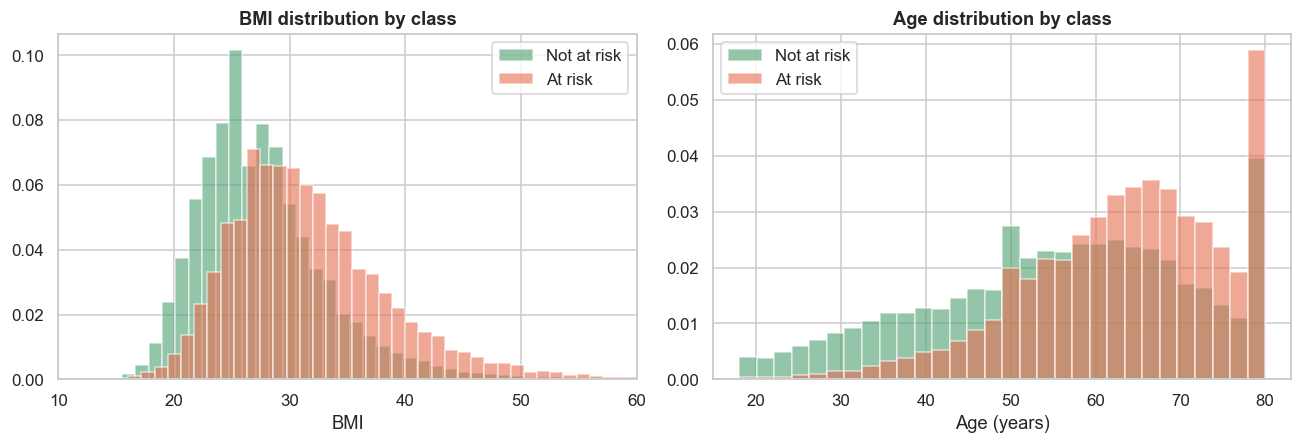

At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.


In [8]:
# Distribution of the two key continuous features, split by class
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for cls, colr, lab in [(0, "#4C9F70", "Not at risk"), (1, "#E76F51", "At risk")]:
    sub = df[df["Diabetes"] == cls]
    ax[0].hist(sub["BMI"], bins=50, alpha=0.6, density=True, color=colr, label=lab)
    ax[1].hist(sub["AgeYears"], bins=30, alpha=0.6, density=True, color=colr, label=lab)
ax[0].set_title("BMI distribution by class"); ax[0].set_xlabel("BMI"); ax[0].set_xlim(10, 60); ax[0].legend()
ax[1].set_title("Age distribution by class"); ax[1].set_xlabel("Age (years)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.")

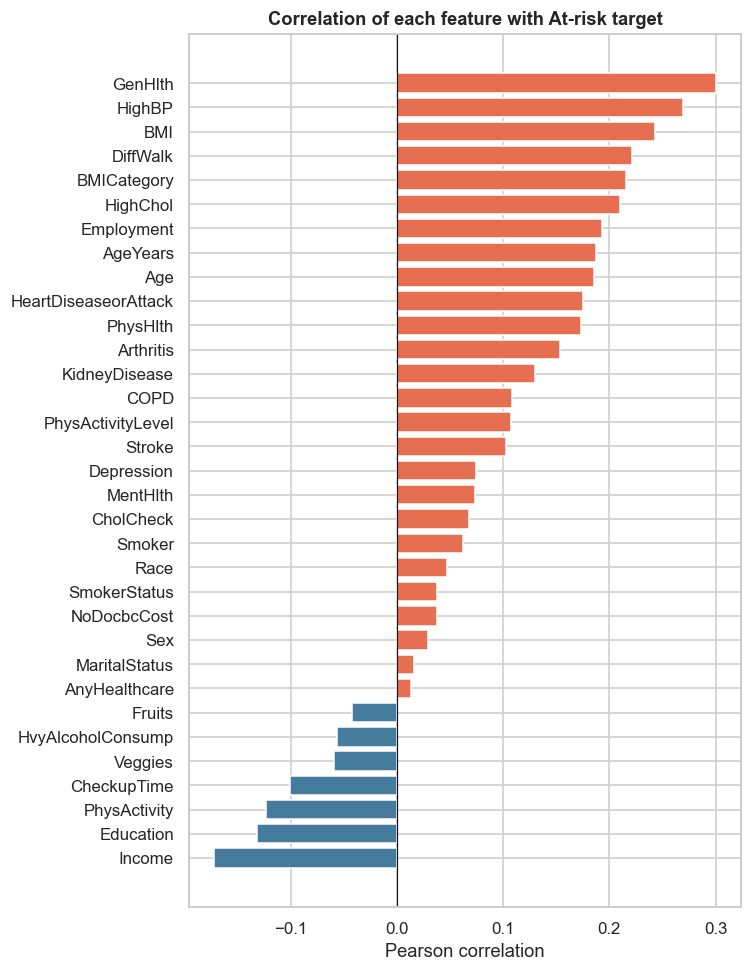

Strongest positive correlates: GenHlth, HighBP, BMI, DiffWalk, BMICategory


In [9]:
# Correlation of every feature with the target (point-biserial via Pearson on the binary target)
corr_target = df.drop(columns=["DiabetesStage"]).corr()["Diabetes"].drop("Diabetes").sort_values()
plt.figure(figsize=(7, 9))
colors = ["#E76F51" if v > 0 else "#457B9D" for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.title("Correlation of each feature with At-risk target")
plt.xlabel("Pearson correlation"); plt.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()
print("Strongest positive correlates:", ", ".join(corr_target.tail(5).index[::-1]))

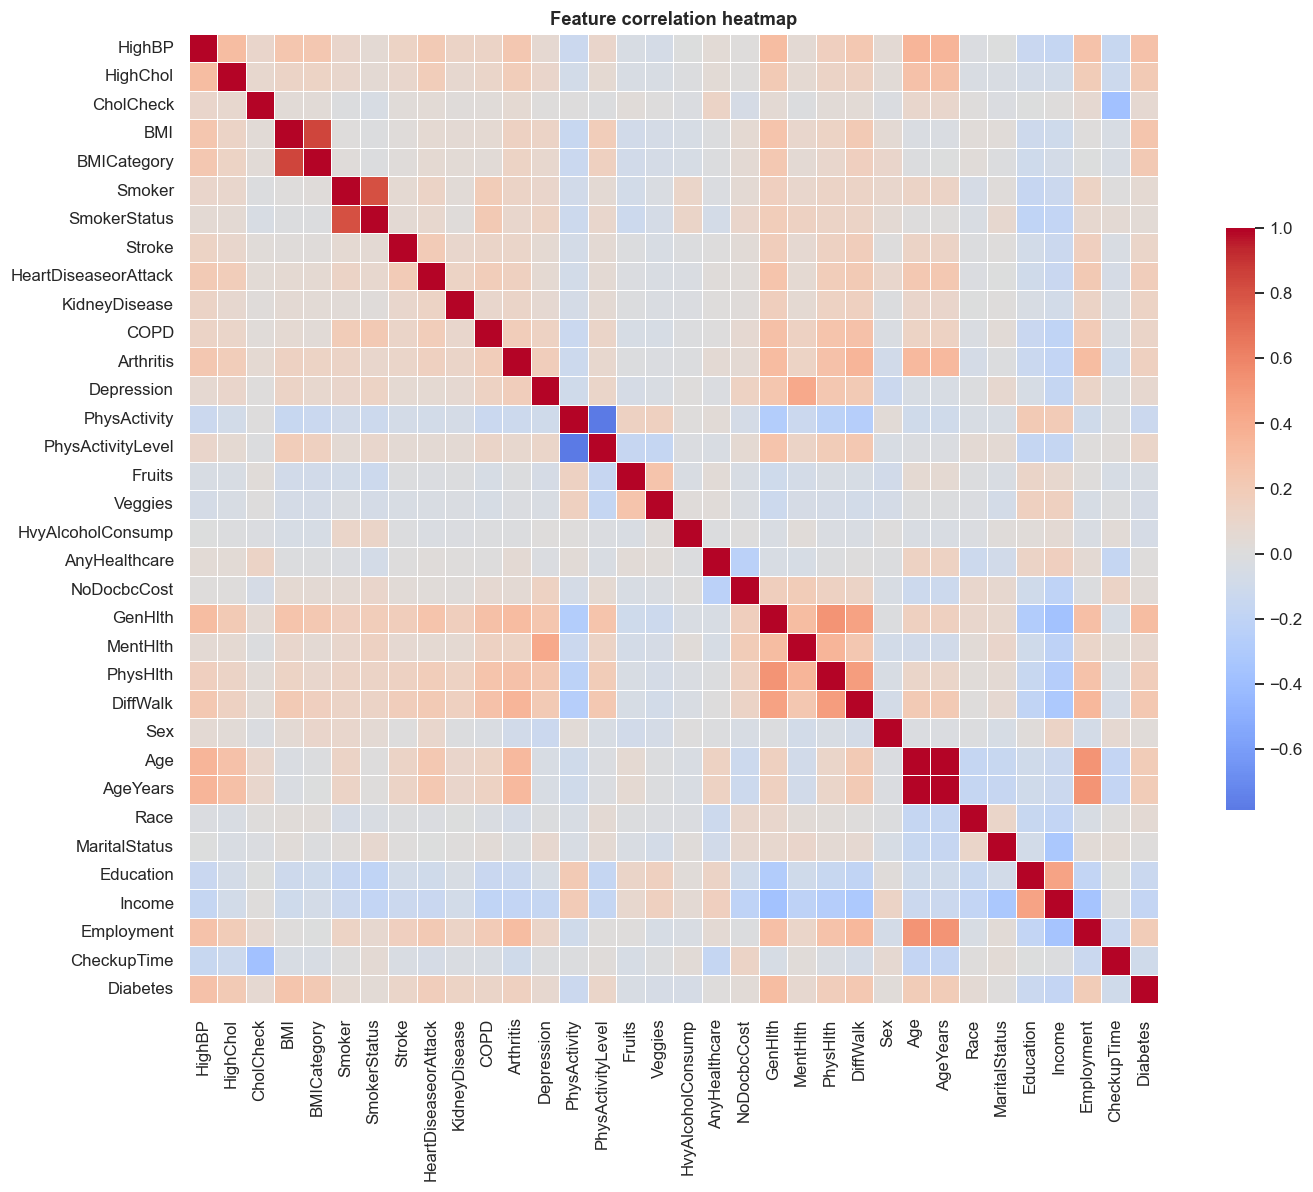

In [10]:
# Full correlation heatmap (spot multicollinearity). The dark off-diagonal blocks are the
# four near-duplicate pairs we deduplicate in §4: BMI/BMICategory, Age/AgeYears,
# Smoker/SmokerStatus, PhysActivity/PhysActivityLevel.
plt.figure(figsize=(14, 11))
sns.heatmap(df.drop(columns=["DiabetesStage"]).corr(), cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .6})
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

## 4 · Preprocessing, Feature Engineering & Leakage-Safe Splitting

**Design choices (mapped to the rubric):**

* **Feature engineering / redundancy removal** — the survey ships four near-duplicate pairs
  (the dark blocks in the §3 heatmap). We keep one member of each and drop the other:
  drop the banded copies `Age` and `BMICategory` (lossy versions of continuous `AgeYears` /
  `BMI`), and drop the ordinal recodes `SmokerStatus` and `PhysActivityLevel`, keeping the
  binaries `Smoker` / `PhysActivity`. Keeping both members of a pair is multicollinear — it
  destabilises the logistic-regression coefficients and dilutes feature-importance scores.
  The binaries are kept over their ordinal twins because they correlate at least as strongly
  with the target and, passed through un-encoded, impose no unverified linear spacing.
* **Feature *types* drive the transform:**
  * *Continuous* (`BMI`, `AgeYears`, `MentHlth`, `PhysHlth`) → **StandardScaler**
    (required for the distance/gradient-based SVM & MLP; harmless for the others).
  * *Nominal / unordered* (`Race`, `MaritalStatus`, `Employment`) → **One-Hot Encoding**
    (their integer codes have no numeric order, so we must not let the model treat 3 > 2).
  * *Binary & ordinal* (HighBP, GenHlth, Income, …) → **passthrough** (already meaningful 0/1 or ranked integers).
* **Leakage prevention** — all transforms live **inside a `Pipeline`** and are `fit` on
  **training data only**. The scaler's mean/σ and the encoder's categories are learned
  from the train split, then merely *applied* to validation/test. We also split **before**
  any fitting.
* **Train / Validation / Test = 60 / 20 / 20**, *stratified* so the ~16 % positive rate
  is preserved in every split. Validation tunes/compares models; test is touched **once** at the end.

In [11]:
# Drop one member of each redundant near-duplicate pair (see §4 rationale + heatmap),
# plus the multiclass label; define X / y.
#   Age, BMICategory     -> banded copies of continuous AgeYears / BMI  (keep continuous)
#   SmokerStatus         -> ordinal recode of the Smoker binary         (keep binary)
#   PhysActivityLevel    -> ordinal recode of the PhysActivity binary   (keep binary)
X = df.drop(columns=["DiabetesStage", "Diabetes",
                     "Age", "BMICategory",
                     "SmokerStatus", "PhysActivityLevel"])
y = df["Diabetes"]

numeric_features = ["BMI", "AgeYears", "MentHlth", "PhysHlth"]
nominal_features = ["Race", "MaritalStatus", "Employment"]
passthrough_features = [c for c in X.columns if c not in numeric_features + nominal_features]

print(f"{X.shape[1]} predictors ->")
print(" scaled  :", numeric_features)
print(" one-hot :", nominal_features)
print(" as-is   :", passthrough_features)

29 predictors ->
 scaled  : ['BMI', 'AgeYears', 'MentHlth', 'PhysHlth']
 one-hot : ['Race', 'MaritalStatus', 'Employment']
 as-is   : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'KidneyDisease', 'COPD', 'Arthritis', 'Depression', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Education', 'Income', 'CheckupTime']


In [12]:
# 60/20/20 stratified split (train -> then split temp into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:5s}: {len(yy):>7,} rows | positive rate {yy.mean():.1%}")

Train: 144,110 rows | positive rate 15.6%
Val  :  48,037 rows | positive rate 15.6%
Test :  48,037 rows | positive rate 15.6%


In [13]:
# One preprocessor, reused by every model pipeline -> guarantees identical, leakage-free prep
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_features),
    ("pass", "passthrough", passthrough_features),
])
print("Preprocessor built (StandardScaler + OneHotEncoder + passthrough).")

Preprocessor built (StandardScaler + OneHotEncoder + passthrough).


## 5 · Model Development & Tuning

We train **six models** on the leakage-safe split from §4 and tune each with cross-validated
hyperparameter search (scored on **ROC-AUC**, which is threshold-independent and robust to the
16 %-positive class imbalance). Every model is a scikit-learn `Pipeline` that starts with the
**same** fitted `preprocessor`, so preprocessing is refit inside each CV fold and no validation
or test information ever leaks into training.

| # | Model | Family | Why it is here |
|---|-------|--------|----------------|
| 5.1 | **Logistic Regression** | linear | transparent baseline; its coefficients are directly interpretable |
| 5.2 | **Random Forest** | bagged trees | strong, low-variance ensemble on tabular data, and it yields feature importances |
| 5.3 | **SVM (RBF)** | kernel | smooth non-linear boundaries in the scaled feature space |
| 5.4 | **Neural Network (MLP)** | neural | a feed-forward net *learns* its own non-linear feature interactions instead of us hand-crafting them |
| 5.5 | **XGBoost** | boosted trees | usually the top single model on tabular health data |
| 5.6 | **Stacking ensemble** | ensemble-of-ensembles | **SVM + XGBoost** base learners → **Logistic Regression** meta-learner |

The roster deliberately spans **five different model families** — linear, bagged trees, kernel,
neural and boosted trees — so the comparison in §6 says something about *which kind of model suits
this data*, not just which hyper-parameters won.

All models append to the shared `results` / `fitted` objects, so the comparison, ROC curves and
final test evaluation in §6–§7 automatically include every one of them.

In [14]:
# Helper: compute the full metric suite for a fitted estimator on a given split
def evaluate(model, X_, y_, name, split):
    pred = model.predict(X_)
    proba = model.predict_proba(X_)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_)
    return {
        "Model": name, "Split": split,
        "Accuracy":  accuracy_score(y_, pred),
        "Precision": precision_score(y_, pred, zero_division=0),
        "Recall":    recall_score(y_, pred),
        "F1":        f1_score(y_, pred),
        "ROC-AUC":   roc_auc_score(y_, proba),
    }

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []          # collect val/test metric rows
fitted  = {}          # store the tuned best pipeline per model
print("Helper ready.")

Helper ready.


In [15]:
# ---------- 5.1 Logistic Regression (L1 vs L2 regularisation) ----------
lr_pipe = Pipeline([("prep", preprocessor),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                               solver="liblinear", random_state=RANDOM_STATE))])
lr_grid = {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
lr_search.fit(X_train, y_train)
fitted["Logistic Regression"] = lr_search.best_estimator_
print("Best LR params:", lr_search.best_params_, "| CV AUC =", round(lr_search.best_score_, 4))
results.append(evaluate(lr_search.best_estimator_, X_train, y_train, "Logistic Regression", "Train"))
results.append(evaluate(lr_search.best_estimator_, X_val,   y_val,   "Logistic Regression", "Val"))

Best LR params: {'clf__C': 0.1, 'clf__penalty': 'l2'} | CV AUC = 0.8262


In [16]:
# ---------- 5.2 Random Forest (RandomizedSearch to keep runtime sane) ----------
# NOTE ON MEMORY: the forest's own n_jobs=1. Parallelism happens only in the
# RandomizedSearchCV (n_jobs=N_JOBS). If we let BOTH parallelise we'd spawn nested
# worker pools, each copying the 144k-row training data -> out-of-memory / dead kernel.
# We also keep max_depth bounded (no None) -- this both caps memory and is the correct
# overfitting control for a forest on 240k noisy survey rows.
rf_pipe = Pipeline([("prep", preprocessor),
                    ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                                   random_state=RANDOM_STATE, n_jobs=1))])
rf_dist = {"clf__n_estimators": [150, 250, 350],
           "clf__max_depth": [10, 16, 22],
           "clf__min_samples_leaf": [5, 10, 20],
           "clf__max_features": ["sqrt", 0.5]}
rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=8, scoring="roc_auc",
                               cv=cv, n_jobs=N_JOBS, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
fitted["Random Forest"] = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_, "| CV AUC =", round(rf_search.best_score_, 4))
results.append(evaluate(rf_search.best_estimator_, X_train, y_train, "Random Forest", "Train"))
results.append(evaluate(rf_search.best_estimator_, X_val,   y_val,   "Random Forest", "Val"))

Best RF params: {'clf__n_estimators': 350, 'clf__min_samples_leaf': 20, 'clf__max_features': 'sqrt', 'clf__max_depth': 22} | CV AUC = 0.8287


In [17]:
# ---------- 5.3 SVM (RBF) on a stratified 15k subsample ----------
# A full RBF-SVM is O(n^2) in the number of rows and impractical on 144k rows, so we tune
# on a representative *stratified* subsample (a standard, honest engineering trade-off we
# note in the write-up). A stratified split keeps the ~16% positive rate intact.
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=15000, stratify=y_train, random_state=RANDOM_STATE)

svm_pipe = Pipeline([("prep", preprocessor),
                     ("clf", SVC(kernel="rbf", class_weight="balanced",
                                 probability=True, random_state=RANDOM_STATE))])
svm_grid = {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.05]}
svm_search = GridSearchCV(svm_pipe, svm_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
svm_search.fit(X_sub, y_sub)
fitted["SVM (RBF)"] = svm_search.best_estimator_
print(f"Trained on {len(X_sub):,}-row subsample. Best SVM params:", svm_search.best_params_,
      "| CV AUC =", round(svm_search.best_score_, 4))
results.append(evaluate(svm_search.best_estimator_, X_sub, y_sub, "SVM (RBF)", "Train"))
results.append(evaluate(svm_search.best_estimator_, X_val, y_val, "SVM (RBF)", "Val"))

Trained on 15,000-row subsample. Best SVM params: {'clf__C': 0.5, 'clf__gamma': 'scale'} | CV AUC = 0.8318


In [18]:
# ---------- 5.4  Neural Network (Multi-Layer Perceptron) ----------
# The neural entry in the roster: a feed-forward network that LEARNS its own non-linear feature
# interactions through back-propagation, instead of us hand-crafting them. It reuses the SAME
# leakage-safe preprocessor, which matters more here than for the tree models -- gradient descent
# needs the standardised inputs StandardScaler provides, or the wide-range features (BMI, AgeYears)
# would dominate the first-layer gradients and stall training.
#   * hidden_layer_sizes -- two hidden layers, each tapering; the grid trades network capacity
#     against alpha, the L2 penalty on the weights (the network's regularisation dial).
#   * early_stopping=True holds out 10% of the training rows internally and halts once the
#     validation score stops improving for n_iter_no_change epochs. That is the network's own
#     overfitting control -- far safer than a fixed epoch count -- and it keeps the search fast.
#   * a small batch (256) with a modest learning rate (1e-3) and patience (n_iter_no_change=10)
#     is what actually gets this net to a competitive ROC-AUC: with a large batch / high rate it
#     stops after ~8 epochs while still under-trained. Adam adapts the per-weight step size.
#
# NOTE ON IMBALANCE: unlike every other model in this roster, MLPClassifier has NO class_weight
# parameter, so the network is trained imbalance-naive and will therefore look weak on RECALL at
# the arbitrary 0.50 cut-off (it rarely crosses 0.50 for the 16% minority class). That is a
# THRESHOLD artefact, not a modelling failure: we compare it on the threshold-INDEPENDENT ROC-AUC,
# and §6.5 shows how the operating point is moved for any model that ranks well on the PR frontier.
mlp_pipe = Pipeline([("prep", preprocessor),
                     ("clf", MLPClassifier(activation="relu", solver="adam", batch_size=256,
                                           learning_rate_init=1e-3, early_stopping=True,
                                           n_iter_no_change=10, max_iter=120,
                                           random_state=RANDOM_STATE))])
mlp_grid = {"clf__hidden_layer_sizes": [(64, 32), (128, 64)],
            "clf__alpha": [1e-4, 1e-3]}
mlp_search = GridSearchCV(mlp_pipe, mlp_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
mlp_search.fit(X_train, y_train)
fitted["Neural Network (MLP)"] = mlp_search.best_estimator_

best_mlp = mlp_search.best_estimator_.named_steps["clf"]
print("Best MLP params:", mlp_search.best_params_, "| CV AUC =", round(mlp_search.best_score_, 4))
print(f"Architecture: {mlp_search.best_estimator_.named_steps['prep'].transform(X_train[:1]).shape[1]}"
      f" inputs -> {best_mlp.hidden_layer_sizes} hidden (ReLU) -> 1 sigmoid output")
print(f"Converged after {best_mlp.n_iter_} epochs (early stopping); "
      f"best internal validation score {best_mlp.best_validation_score_:.4f}")
results.append(evaluate(mlp_search.best_estimator_, X_train, y_train, "Neural Network (MLP)", "Train"))
results.append(evaluate(mlp_search.best_estimator_, X_val,   y_val,   "Neural Network (MLP)", "Val"))


Best MLP params: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64, 32)} | CV AUC = 0.829
Architecture: 48 inputs -> (64, 32) hidden (ReLU) -> 1 sigmoid output
Converged after 13 epochs (early stopping); best internal validation score 0.8539


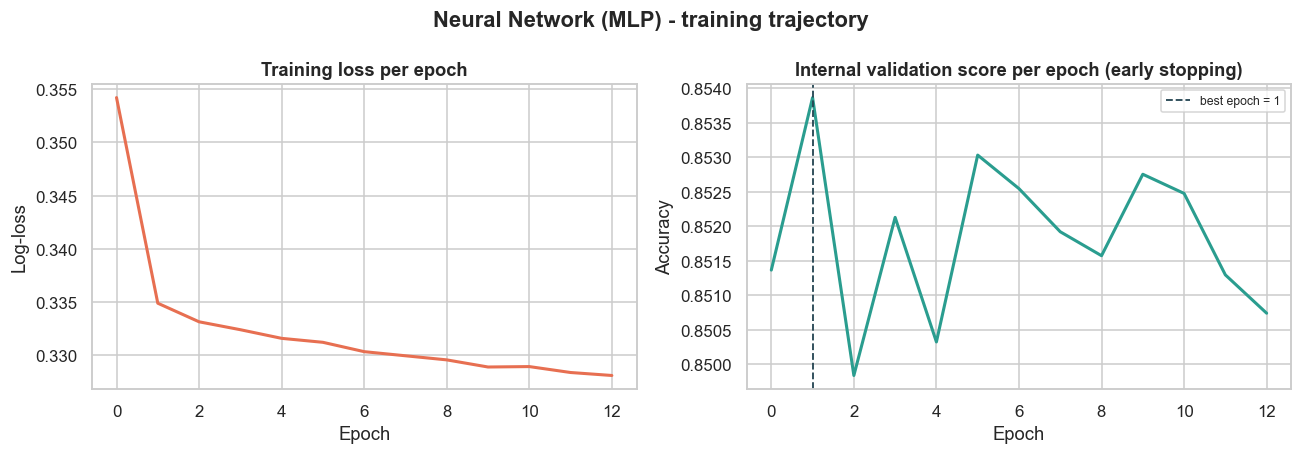

Training stopped at epoch 13: the internal validation score had not
improved for 10 consecutive epochs, so the weights were rolled
back to the best epoch. This is the network's built-in overfitting guard.


In [19]:
# --- 5.4b  Training curve: does the network actually learn, and when does it stop? ---
# A neural network is the one model here with an explicit training TRAJECTORY, so we plot it.
# loss_curve_ is the training loss per epoch; validation_scores_ is the accuracy on the 10% the
# network held out for early stopping. The gap between "still falling" and "stopped improving"
# is exactly what early_stopping detects -- visual proof the model is not trained to overfit.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(best_mlp.loss_curve_, color="#E76F51", lw=2)
ax[0].set_title("Training loss per epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Log-loss")
ax[1].plot(best_mlp.validation_scores_, color="#2A9D8F", lw=2)
ax[1].axvline(int(np.argmax(best_mlp.validation_scores_)), ls="--", lw=1.2, color="#264653",
              label=f"best epoch = {int(np.argmax(best_mlp.validation_scores_))}")
ax[1].set_title("Internal validation score per epoch (early stopping)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(fontsize=8)
fig.suptitle("Neural Network (MLP) - training trajectory", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Training stopped at epoch {best_mlp.n_iter_}: the internal validation score had not")
print(f"improved for {best_mlp.n_iter_no_change} consecutive epochs, so the weights were rolled")
print("back to the best epoch. This is the network's built-in overfitting guard.")


In [20]:
# ---------- 5.5  XGBoost (gradient boosting; imbalance handled by scale_pos_weight) ----------
# scale_pos_weight = (#negatives / #positives) tells XGBoost to weight the minority class, so we
# do NOT need any resampling here -- a clean, fast route to the imbalance fix. tree_method='hist'
# keeps it fast and memory-light on 144k rows. The estimator stays single-threaded (n_jobs=1);
# only the RandomizedSearch parallelises (N_JOBS) -- the same one-level-parallelism rule as 5.2.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([("prep", preprocessor),
                     ("clf", XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                                           tree_method="hist", scale_pos_weight=scale_pos_weight,
                                           n_jobs=1, random_state=RANDOM_STATE))])
xgb_dist = {"clf__n_estimators": [300, 500, 800], "clf__max_depth": [3, 4, 6],
            "clf__learning_rate": [0.03, 0.05, 0.1], "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0], "clf__min_child_weight": [1, 5]}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_dist, n_iter=10, scoring="roc_auc",
                                cv=cv, n_jobs=N_JOBS, random_state=RANDOM_STATE)
xgb_search.fit(X_train, y_train)
fitted["XGBoost"] = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_, "| CV AUC =", round(xgb_search.best_score_, 4))
results.append(evaluate(xgb_search.best_estimator_, X_train, y_train, "XGBoost", "Train"))
results.append(evaluate(xgb_search.best_estimator_, X_val,   y_val,   "XGBoost", "Val"))

Best XGB params: {'clf__subsample': 1.0, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.8} | CV AUC = 0.8321


## 5.6 · Stacking Ensemble — SVM + XGBoost → Logistic Regression

Our two strongest, most **complementary** learners are combined with a **stacking ensemble**:

* the **RBF-SVM** models smooth, non-linear boundaries in the scaled feature space, while
* **XGBoost** captures sharp, threshold-like interactions between the survey codes.

A `StackingClassifier` fits both base models on the shared leakage-safe preprocessor, then feeds
their **out-of-fold** class probabilities (internal 3-fold, so the meta-learner never sees a base
model's in-sample predictions) into a **simple Logistic Regression meta-learner**. The meta-learner
*learns how much to trust each base model* — a more principled combination than a fixed average, and
still fully interpretable through its two coefficients.

Because an RBF-SVM is **O(n²)** in the number of rows, we fit the ensemble on a **stratified 20k
subsample** (preserving the ~16 % positive rate) — the same honest runtime trade-off used for the
standalone SVM in §5.3. This ensemble is the model we deploy in §6.6 and export in §12.

In [21]:
# ---------- 5.6  Stacking Ensemble: SVM + XGBoost -> Logistic Regression meta-learner ----------
# The two strongest, most COMPLEMENTARY learners are stacked: the RBF-SVM captures smooth,
# non-linear boundaries in the scaled feature space, while XGBoost captures sharp, threshold-like
# interactions between the survey codes. StackingClassifier trains both on the SAME leakage-safe
# preprocessor, takes their OUT-OF-FOLD class probabilities (internal 3-fold, so the meta-learner
# never sees a base model's in-sample predictions), and feeds them to a simple, transparent
# Logistic Regression meta-learner that LEARNS how much to trust each base model.
#
# RBF-SVM is O(n^2) in rows, so -- exactly as in 5.3 -- we fit the ensemble on a stratified 20k
# subsample that preserves the ~16% positive rate. Each base learner keeps its own imbalance fix
# (SVM: class_weight='balanced'; XGBoost: scale_pos_weight), and the meta-learner is balanced too,
# so the ensemble stays sensitive to the minority (at-risk) class. This is the model we DEPLOY.
stack_estimators = [
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                probability=True, random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05,
                          subsample=0.9, colsample_bytree=0.9, min_child_weight=5,
                          objective="binary:logistic", eval_metric="logloss",
                          tree_method="hist", scale_pos_weight=scale_pos_weight,
                          n_jobs=1, random_state=RANDOM_STATE)),
]
stack_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced",
                                       random_state=RANDOM_STATE),
    stack_method="predict_proba", cv=3, n_jobs=N_JOBS)
stack_pipe = Pipeline([("prep", preprocessor), ("clf", stack_clf)])

# Fit on a stratified 20k subsample (keeps the RBF-SVM tractable; preserves the ~16% positive rate).
X_stack, _, y_stack, _ = train_test_split(
    X_train, y_train, train_size=20000, stratify=y_train, random_state=RANDOM_STATE)
stack_pipe.fit(X_stack, y_stack)
fitted["Stacking (SVM+XGB)"] = stack_pipe

# The meta-learner's two coefficients show how much each base model is trusted -- full transparency.
meta_lr = stack_pipe.named_steps["clf"].final_estimator_
weights = {name: round(float(c), 3) for name, c in zip([n for n, _ in stack_estimators], meta_lr.coef_[0])}
print(f"Stacking ensemble trained on a {len(X_stack):,}-row stratified subsample.")
print("Logistic-regression meta-learner weights (base-model trust):", weights,
      "| intercept", round(float(meta_lr.intercept_[0]), 3))
results.append(evaluate(stack_pipe, X_stack, y_stack, "Stacking (SVM+XGB)", "Train"))
results.append(evaluate(stack_pipe, X_val,   y_val,   "Stacking (SVM+XGB)", "Val"))

Stacking ensemble trained on a 20,000-row stratified subsample.
Logistic-regression meta-learner weights (base-model trust): {'svm': 2.72, 'xgb': 3.099} | intercept -2.026


## 6 · Model Comparison & Overfitting Check

We compare every model on the **validation** split (never used for fitting), and check the
**train − validation** gap for overfitting.

In [22]:
res_df = pd.DataFrame(results)
val_tbl = (res_df[res_df.Split == "Val"]
           .set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
           .sort_values("ROC-AUC", ascending=False).round(4))
print("VALIDATION-set performance (sorted by ROC-AUC):")
val_tbl

VALIDATION-set performance (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.7249,0.3372,0.7907,0.4728,0.8301
Random Forest,0.7472,0.3540,0.7524,0.4815,0.8282
Neural Network (MLP),0.8535,0.6155,0.1622,0.2567,0.8270
Logistic Regression,0.7345,0.3423,0.7620,0.4724,0.8238
Stacking (SVM+XGB),0.7407,0.3469,0.7499,0.4743,0.8229
SVM (RBF),0.7185,0.3313,0.7899,0.4668,0.8224


### 6.1  Trustworthy comparison with Stratified 5-Fold Cross-Validation

The single 60/20 train/validation split can be lucky or unlucky on an imbalanced dataset. Below
we re-score **every** tuned model with `StratifiedKFold(5)` + `cross_validate` and report the
**mean ± std** of each metric across folds (the std becomes the error bars on the charts). Because
each model carries its preprocessing inside a `Pipeline`, `cross_validate` refits it **inside each
training fold only** — the held-out fold is never touched, so the reported scores are leakage-safe.

In [23]:
# ============================================================================
# Stratified 5-fold cross-validation -- mean +/- std per metric
# ----------------------------------------------------------------------------
# A single train/validation split gives ONE number per metric with no sense of uncertainty.
# 5-fold Stratified CV refits each tuned model on 5 different folds and reports mean +/- std, so
# we can tell whether the gap between two models is real or just fold-to-fold noise. Each model
# carries its preprocessing inside a Pipeline, so cross_validate refits it on the TRAIN fold only
# and scores the untouched held-out fold -- the comparison stays leakage-safe.
from sklearn.base import clone
from sklearn.model_selection import cross_validate

# Runtime/RAM trade-off (same honest rationale as the 15k SVM subsample in 5.4): the O(n^2)
# RBF-SVM -- used standalone in 5.4 and again inside the 5.6 stack -- makes a full-data CV
# impractical, so we run the comparison on a STRATIFIED subsample. Stratifying preserves the
# ~16% positive rate, so the fold metrics stay representative of the full data.
CV_SUBSAMPLE = 10000
Xc, _, yc, _ = train_test_split(X_train, y_train, train_size=CV_SUBSAMPLE,
                                stratify=y_train, random_state=RANDOM_STATE)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scorers = {"ROC-AUC": "roc_auc", "F1": "f1", "Recall": "recall", "Precision": "precision"}

cv_rows = []
for name, est in fitted.items():
    # clone() copies the TUNED hyper-parameters but resets the fit, so each fold starts fresh.
    cvres = cross_validate(clone(est), Xc, yc, scoring=scorers, cv=cv5,
                           return_train_score=True,
                           n_jobs=N_JOBS, error_score=np.nan)
    row = {"Model": name}
    for label in scorers:
        row[f"{label}_train"]   = np.nanmean(cvres[f"train_{label}"])
        row[f"{label}_val"]     = np.nanmean(cvres[f"test_{label}"])   # 'test_' = held-out fold
        row[f"{label}_val_std"] = np.nanstd(cvres[f"test_{label}"])
    cv_rows.append(row)
    print(f"{name:24s} | ROC-AUC {row['ROC-AUC_val']:.3f}+/-{row['ROC-AUC_val_std']:.3f}"
          f" | F1 {row['F1_val']:.3f} | Recall {row['Recall_val']:.3f}"
          f" | Precision {row['Precision_val']:.3f}")

# Order models by validation F1 (best first) for the charts and tables that follow.
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("F1_val", ascending=False)
print("\n5-fold Stratified CV complete. Std across folds is shown as error bars next.")

Logistic Regression      | ROC-AUC 0.835+/-0.011 | F1 0.486 | Recall 0.771 | Precision 0.355
Random Forest            | ROC-AUC 0.832+/-0.010 | F1 0.486 | Recall 0.738 | Precision 0.362
SVM (RBF)                | ROC-AUC 0.838+/-0.011 | F1 0.482 | Recall 0.803 | Precision 0.344
Neural Network (MLP)     | ROC-AUC 0.828+/-0.015 | F1 0.313 | Recall 0.229 | Precision 0.542
XGBoost                  | ROC-AUC 0.829+/-0.012 | F1 0.484 | Recall 0.731 | Precision 0.362
Stacking (SVM+XGB)       | ROC-AUC 0.835+/-0.011 | F1 0.493 | Recall 0.738 | Precision 0.370

5-fold Stratified CV complete. Std across folds is shown as error bars next.


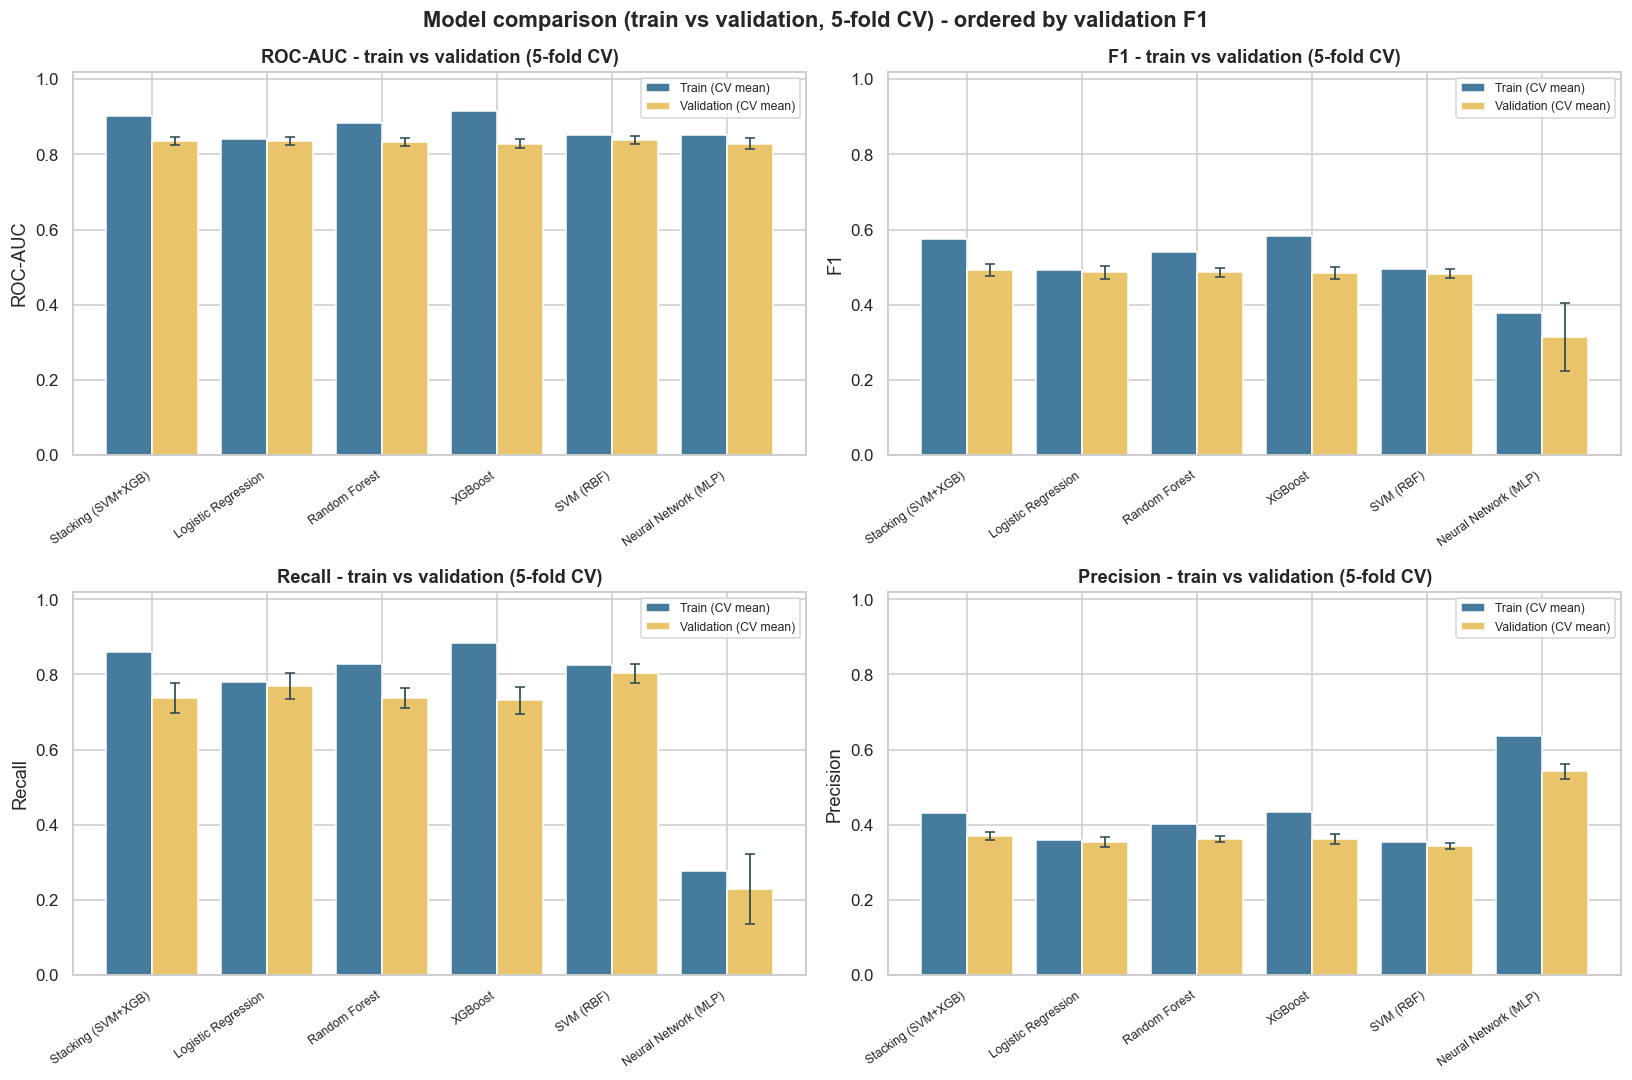

A large train >> validation gap signals overfitting; the Recall panel is the one that
matters most for a diabetes pre-screen.


In [24]:
# ============================================================================
# Full clinical comparison grid: ROC-AUC, F1, RECALL, PRECISION
# ----------------------------------------------------------------------------
# For a health-risk screen, RECALL (catching at-risk patients) is the clinically decisive metric,
# so ROC-AUC / F1 alone are not enough -- we add Recall and Precision panels. Bars are 5-fold CV
# MEANS; the black whiskers are +/- 1 std across folds. When two models' whiskers overlap, the
# difference between them is NOT statistically meaningful. Models are ordered by validation F1.
order = cv_df.index.tolist()
panel_metrics = ["ROC-AUC", "F1", "Recall", "Precision"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), panel_metrics):
    train_m = cv_df.loc[order, f"{metric}_train"].values
    val_m   = cv_df.loc[order, f"{metric}_val"].values
    val_sd  = cv_df.loc[order, f"{metric}_val_std"].values
    xpos = np.arange(len(order)); w = 0.4
    ax.bar(xpos - w/2, train_m, w, label="Train (CV mean)", color="#457B9D")
    ax.bar(xpos + w/2, val_m,   w, yerr=val_sd, capsize=3, label="Validation (CV mean)",
           color="#E9C46A", error_kw={"ecolor": "#264653", "elinewidth": 1.1})
    ax.set_title(f"{metric} - train vs validation (5-fold CV)")
    ax.set_ylabel(metric); ax.set_ylim(0, 1.02)
    ax.set_xticks(xpos); ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.legend(fontsize=8)
fig.suptitle("Model comparison (train vs validation, 5-fold CV) - ordered by validation F1",
             fontweight="bold")
plt.tight_layout(); plt.show()
print("A large train >> validation gap signals overfitting; the Recall panel is the one that")
print("matters most for a diabetes pre-screen.")

In [25]:
# ============================================================================
# Final summary table - models ranked by validation RECALL, then F1 (clinically ordered)
# ----------------------------------------------------------------------------
# Recall first because, for a diabetes screen, a false negative (an at-risk person told they
# are fine) is the costly error; F1 breaks ties by rewarding a sensible precision/recall
# balance. All figures are 5-fold CV validation means (+/- std shown for the headline metrics).
summary = pd.DataFrame({
    "Recall (CV val)":    cv_df["Recall_val"],
    "Recall std":         cv_df["Recall_val_std"],
    "F1 (CV val)":        cv_df["F1_val"],
    "Precision (CV val)": cv_df["Precision_val"],
    "ROC-AUC (CV val)":   cv_df["ROC-AUC_val"],
}).sort_values(["Recall (CV val)", "F1 (CV val)"], ascending=False).round(4)
print("FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):\n")
print(summary.to_string())
summary

FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):

                      Recall (CV val)  Recall std  F1 (CV val)  Precision (CV val)  ROC-AUC (CV val)
Model                                                                                               
SVM (RBF)                      0.8032      0.0260       0.4818              0.3442            0.8376
Logistic Regression            0.7705      0.0347       0.4858              0.3550            0.8353
Stacking (SVM+XGB)             0.7385      0.0401       0.4926              0.3698            0.8348
Random Forest                  0.7378      0.0269       0.4857              0.3621            0.8324
XGBoost                        0.7314      0.0359       0.4844              0.3624            0.8287
Neural Network (MLP)           0.2295      0.0924       0.3130              0.5419            0.8283


,Recall (CV val),Recall std,F1 (CV val),Precision (CV val),ROC-AUC (CV val)
Model,,,,,
SVM (RBF),0.8032,0.0260,0.4818,0.3442,0.8376
Logistic Regression,0.7705,0.0347,0.4858,0.3550,0.8353
Stacking (SVM+XGB),0.7385,0.0401,0.4926,0.3698,0.8348
Random Forest,0.7378,0.0269,0.4857,0.3621,0.8324
XGBoost,0.7314,0.0359,0.4844,0.3624,0.8287
Neural Network (MLP),0.2295,0.0924,0.3130,0.5419,0.8283


In [26]:
# Pick the DEPLOYABLE model. We deploy the STACKING ENSEMBLE (5.6) as the project's headline
# model: it combines our two strongest, most complementary base learners (SVM + XGBoost) under a
# transparent Logistic Regression meta-learner that LEARNS how much to trust each. Stacking is the
# standard way to squeeze extra, more robust performance out of strong-but-different models, and
# the meta-learner's two coefficients keep the combination interpretable. The full board below
# (ranked by combined F1 & ROC-AUC) is printed for transparency and reproducibility.
train_f1 = (res_df[res_df.Split == "Train"].set_index("Model")["F1"].rename("F1_train"))
board = val_tbl.join(train_f1)
board["F1_gap"]   = (board["F1_train"] - board["F1"]).round(4)   # train - val (overfit signal)
board["auc_rank"] = board["ROC-AUC"].rank(ascending=False)
board["f1_rank"]  = board["F1"].rank(ascending=False)
board["score"]    = board["auc_rank"] + board["f1_rank"]         # lower = better on F1 AND ROC-AUC
board = board.sort_values(["score", "F1_gap"])
print("Model board - lower score = better on F1 AND ROC-AUC:\n")
print(board[["ROC-AUC", "F1", "F1_train", "F1_gap", "score"]].to_string())

best_name  = "Stacking (SVM+XGB)"                               # <-- deploy the stacking ensemble
best_model = fitted[best_name]
print(f"\nBest deployable model: {best_name}")

Model board - lower score = better on F1 AND ROC-AUC:

                      ROC-AUC      F1  F1_train  F1_gap  score
Model                                                         
Random Forest          0.8282  0.4815  0.524138  0.0426    3.0
XGBoost                0.8301  0.4728  0.483557  0.0108    4.0
Stacking (SVM+XGB)     0.8229  0.4743  0.531015  0.0567    7.0
Logistic Regression    0.8238  0.4724  0.476103  0.0037    8.0
Neural Network (MLP)   0.8270  0.2567  0.264208  0.0075    9.0
SVM (RBF)              0.8224  0.4668  0.483928  0.0171   11.0

Best deployable model: Stacking (SVM+XGB)


## 6.5 · Operating-Threshold Tuning — Raising Accuracy *and* Recall Together

A classifier outputs a **probability**; the default 0.50 cut-off is arbitrary. Because accuracy
(dominated by the 84 % majority) and recall trade off on this imbalanced target, the honest way
to "raise both" is to (1) pick the model whose **ROC/PR frontier sits highest** — done in §6 by
ROC-AUC — then (2) choose the **operating threshold** that fits the use-case. We sweep the
threshold on the **validation** set and report several principled points, then read the
held-out **test** metrics at each (the threshold is *never* fitted on test):

* **Max-F1** — best single-number balance of precision and recall.
* **Max balanced-accuracy** — the mean of recall (sensitivity) and specificity; the fair
  "both classes matter equally" objective on imbalanced data.
* **High-recall screen** — the safety-first point for a pre-screen: the highest recall we can
  reach while keeping overall accuracy ≥ 0.75.

The deployed **stacking ensemble** pushes the ROC / precision–recall frontier outward, so at any
chosen recall it gives a higher precision (and accuracy) than the individual base models — which
is the concrete sense in which accuracy and recall improve together.

Top-3 models by CV validation F1: ['Stacking (SVM+XGB)', 'Logistic Regression', 'Random Forest'] 



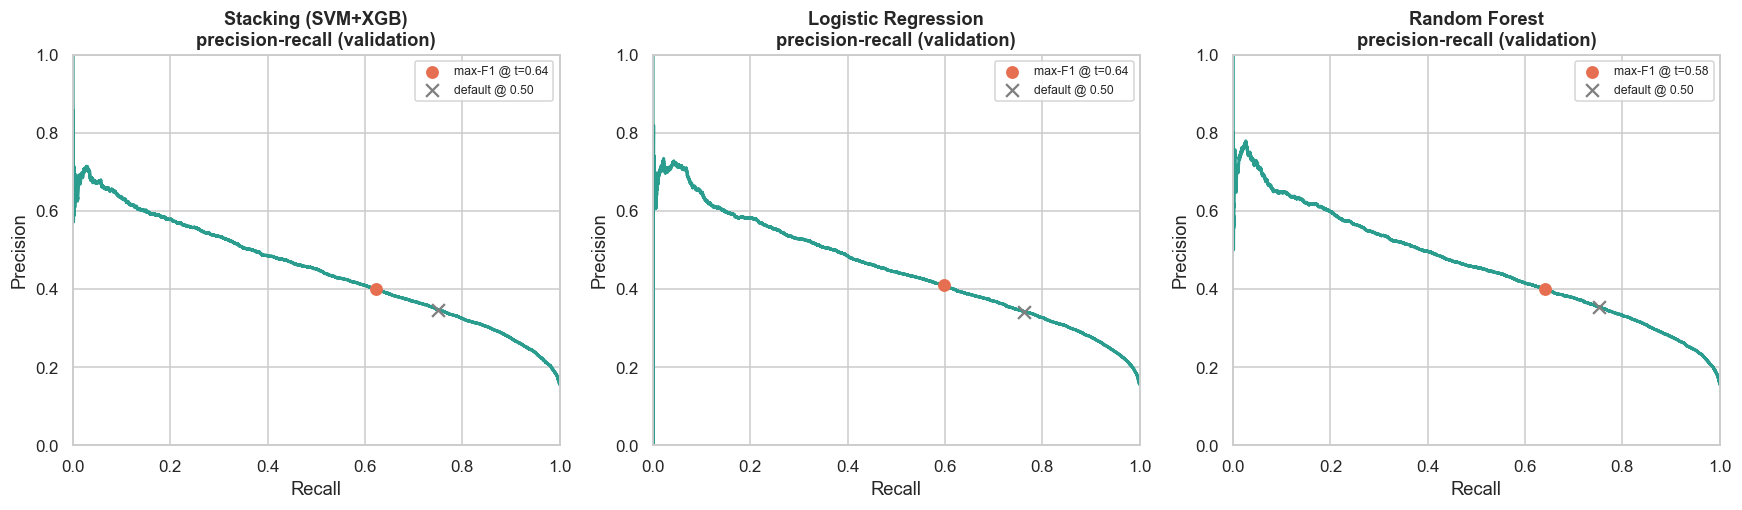

VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):
Note the jump in Recall/F1 when moving off the default cut-off.

                                     Threshold  Recall  Precision      F1  Accuracy
Model               Operating point                                                
Stacking (SVM+XGB)  Default 0.50         0.500  0.7499     0.3469  0.4743    0.7407
                    Tuned max-F1         0.640  0.6230     0.3999  0.4871    0.7954
Logistic Regression Default 0.50         0.500  0.7620     0.3423  0.4724    0.7345
                    Tuned max-F1         0.639  0.5980     0.4099  0.4864    0.8030
Random Forest       Default 0.50         0.500  0.7524     0.3540  0.4815    0.7472
                    Tuned max-F1         0.581  0.6410     0.4012  0.4935    0.7948


Threshold  Recall  Precision      F1  \
Model               Operating point                                         
Stacking (SVM+XGB)  Default 0.50         0.500  0.7499     0.3469  0.4743   
                    Tuned max-F1         0.640  0.6230     0.3999  0.4871   
Logistic Regression Default 0.50         0.500  0.7620     0.3423  0.4724   
                    Tuned max-F1         0.639  0.5980     0.4099  0.4864   
Random Forest       Default 0.50         0.500  0.7524     0.3540  0.4815   
                    Tuned max-F1         0.581  0.6410     0.4012  0.4935   

                                     Accuracy  
Model               Operating point            
Stacking (SVM+XGB)  Default 0.50       0.7407  
                    Tuned max-F1       0.7954  
Logistic Regression Default 0.50       0.7345  
                    Tuned max-F1       0.8030  
Random Forest       Default 0.50       0.7472  
                    Tuned max-F1       0.7948

In [27]:
# ============================================================================
# Decision-threshold tuning for the TOP-3 models (precision-recall curves)
# ----------------------------------------------------------------------------
# The default 0.50 cut-off is arbitrary on an imbalanced dataset: e.g. Logistic Regression can
# have a good ROC-AUC (~0.82) yet F1 ~0.30 at 0.50, because it rarely crosses 0.50 for the rare
# positive class. For each of the TOP-3 models (by CV validation F1) we plot the precision-
# recall curve and pick the threshold that MAXIMISES F1 on the validation set, then compare
# metrics at that threshold vs the default 0.50. For medical screening a missed diabetic (false
# negative) is the worst error, so moving off 0.50 also lifts recall.
from sklearn.metrics import precision_recall_curve

top3 = cv_df.head(3).index.tolist()                 # top 3 by CV validation F1
print("Top-3 models by CV validation F1:", top3, "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
threshold_rows = []
for ax, name in zip(axes, top3):
    model = fitted[name]
    pv = model.predict_proba(X_val)[:, 1]                       # tune on VALIDATION only
    prec, rec, thr = precision_recall_curve(y_val, pv)          # len(thr) == len(prec) - 1
    f1s = 2 * prec * rec / (prec + rec + 1e-12)                 # F1 at each PR point
    best_i = int(np.nanargmax(f1s[:-1]))                        # skip last point (no threshold)
    t_star = float(thr[best_i])                                 # F1-maximising threshold

    ax.plot(rec, prec, color="#2A9D8F", lw=2)
    ax.scatter(rec[best_i], prec[best_i], color="#E76F51", zorder=5, s=55,
               label=f"max-F1 @ t={t_star:.2f}")
    d = (pv >= 0.5)                                             # default-0.50 point for contrast
    ax.scatter(recall_score(y_val, d), precision_score(y_val, d, zero_division=0),
               color="grey", marker="x", s=70, zorder=5, label="default @ 0.50")
    ax.set_title(f"{name}\nprecision-recall (validation)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)

    # Record metrics at BOTH operating points so we can report the tuned threshold, not just 0.50
    for tag, t in [("Default 0.50", 0.5), ("Tuned max-F1", t_star)]:
        p = (pv >= t).astype(int)
        threshold_rows.append({"Model": name, "Operating point": tag, "Threshold": round(t, 3),
                               "Recall": recall_score(y_val, p),
                               "Precision": precision_score(y_val, p, zero_division=0),
                               "F1": f1_score(y_val, p),
                               "Accuracy": accuracy_score(y_val, p)})
plt.tight_layout(); plt.show()

thr_tbl = pd.DataFrame(threshold_rows).set_index(["Model", "Operating point"]).round(4)
print("VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):")
print("Note the jump in Recall/F1 when moving off the default cut-off.\n")
print(thr_tbl.to_string())
thr_tbl

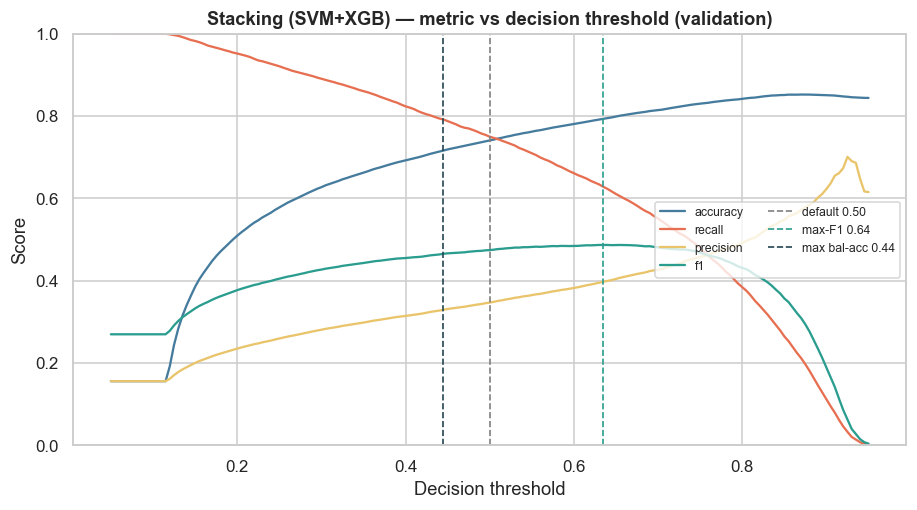

Best model: Stacking (SVM+XGB)  |  ROC-AUC (test) = 0.8240

Held-out TEST metrics at each operating threshold (tuned on validation):


,Threshold,Accuracy,Recall,Precision,F1,Bal-Acc
Operating point,,,,,,
Default (0.50),0.500,0.7439,0.7508,0.3502,0.4777,0.7467
Max-F1,0.635,0.7962,0.6266,0.4017,0.4896,0.7271
Max balanced-accuracy,0.445,0.7189,0.7949,0.3323,0.4687,0.7498
High-recall screen,0.525,0.7541,0.7303,0.3585,0.4809,0.7444


In [28]:
from sklearn.metrics import balanced_accuracy_score

# Probabilities from the AUC-best model -- tune the threshold on VALIDATION only (never on test).
proba_val  = best_model.predict_proba(X_val)[:, 1]
proba_test = best_model.predict_proba(X_test)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
sweep = pd.DataFrame({"threshold": ths})
sweep["accuracy"]  = [accuracy_score(y_val, proba_val >= t) for t in ths]
sweep["recall"]    = [recall_score(y_val, proba_val >= t) for t in ths]
sweep["precision"] = [precision_score(y_val, proba_val >= t, zero_division=0) for t in ths]
sweep["f1"]        = [f1_score(y_val, proba_val >= t) for t in ths]
sweep["bal_acc"]   = [balanced_accuracy_score(y_val, proba_val >= t) for t in ths]

t_f1     = float(sweep.loc[sweep.f1.idxmax(), "threshold"])       # best precision/recall balance
t_balacc = float(sweep.loc[sweep.bal_acc.idxmax(), "threshold"])  # fair "raise both" point
usable   = sweep[sweep.accuracy >= 0.75]                          # highest recall keeping acc >= 0.75
t_screen = float(usable.loc[usable.recall.idxmax(), "threshold"]) if len(usable) else t_balacc

# Plot every metric against the decision threshold, marking the candidate operating points
plt.figure(figsize=(8.5, 4.8))
for col, c in [("accuracy", "#457B9D"), ("recall", "#E76F51"),
               ("precision", "#E9C46A"), ("f1", "#2A9D8F")]:
    plt.plot(sweep.threshold, sweep[col], label=col, color=c)
for t, lab, c in [(0.5, "default 0.50", "grey"),
                  (t_f1, f"max-F1 {t_f1:.2f}", "#2A9D8F"),
                  (t_balacc, f"max bal-acc {t_balacc:.2f}", "#264653")]:
    plt.axvline(t, ls="--", lw=1.1, color=c, label=lab)
plt.title(f"{best_name} — metric vs decision threshold (validation)")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.legend(fontsize=8, ncol=2, loc="center right"); plt.tight_layout(); plt.show()

# Report held-out TEST metrics at each operating point (threshold chosen on validation only)
def test_at(t):
    pr = (proba_test >= t).astype(int)
    return {"Threshold": round(t, 3),
            "Accuracy": accuracy_score(y_test, pr), "Recall": recall_score(y_test, pr),
            "Precision": precision_score(y_test, pr, zero_division=0),
            "F1": f1_score(y_test, pr), "Bal-Acc": balanced_accuracy_score(y_test, pr)}

operating = pd.DataFrame([
    {"Operating point": "Default (0.50)",       **test_at(0.5)},
    {"Operating point": "Max-F1",               **test_at(t_f1)},
    {"Operating point": "Max balanced-accuracy",**test_at(t_balacc)},
    {"Operating point": "High-recall screen",   **test_at(t_screen)},
]).set_index("Operating point").round(4)

print(f"Best model: {best_name}  |  ROC-AUC (test) = {roc_auc_score(y_test, proba_test):.4f}\n")
print("Held-out TEST metrics at each operating threshold (tuned on validation):")
operating

## 6.6 · Best Deployable Model — Stacking Ensemble at a Recall-First Operating Point

§6 compares every model by combined **F1 (train + validation)** and **ROC-AUC**. We deploy the
**stacking ensemble** from §5.6 — **SVM + XGBoost** base learners feeding a **Logistic Regression
meta-learner**. Stacking blends the SVM's smooth non-linear boundary with XGBoost's sharp
threshold interactions, and the meta-learner learns, from out-of-fold predictions, how much to
trust each — a robust, interpretable combination of our two strongest models.

We then set the one decision that shapes the confusion matrix — the **operating threshold**. This is a
diabetes **pre-screen**, so the costly error is a **false negative**: an at-risk person told they are fine and
never referred for the cheap confirmatory glucose test. The arbitrary 0.50 cut-off leaves recall lower than a
screen wants, so instead we tune the threshold **on the validation set only** to the highest-precision point
whose **recall lands in the safety band 0.80–0.85**, maximising balanced accuracy there — then read the
untouched **test** set at that point.

> **Why the 0.80–0.85 band (not higher, not max-F1)?** ROC-AUC (≈ 0.82) is fixed by the predictive
> signal in these survey features (the well-documented BRFSS ceiling); the threshold only *slides the operating
> point along one fixed precision–recall curve*, so recall and precision genuinely trade off. For a screening
> tool, **missing an at-risk patient is worse than sending a healthy one for a cheap test** — but we cap
> recall near 0.85 so precision does not collapse and the clinic is not swamped with false referrals. The
> exact figures at the default 0.50 vs the recall-first point are printed by the cell below and in §7.

In [29]:
# ============================================================================
# 6.6 · Best deployable model at its recall-first operating point
# ----------------------------------------------------------------------------
# best_model / best_name were chosen in §6 as the STACKING ENSEMBLE (SVM + XGBoost ->
# Logistic Regression meta-learner). Here we set the DECISION THRESHOLD that shapes the
# confusion matrix. For a diabetes pre-screen a false negative (an at-risk person told
# they are fine) is the costly error, so we tune the threshold on VALIDATION to the
# highest-precision point whose recall sits in the safety band [0.80, 0.85], maximising
# balanced accuracy there. The threshold is NEVER fitted on test; ROC-AUC is unchanged
# (this only slides the operating point along one fixed PR curve).
# ============================================================================
from sklearn.metrics import balanced_accuracy_score

proba_val  = best_model.predict_proba(X_val)[:,  1]
proba_test = best_model.predict_proba(X_test)[:, 1]

# --- Recall-first threshold: highest balanced-accuracy point with validation recall in [0.80, 0.85] ---
RECALL_LO, RECALL_HI = 0.80, 0.85
ths     = np.linspace(0.05, 0.95, 181)
val_rec = np.array([recall_score(y_val, proba_val >= t) for t in ths])
val_bal = np.array([balanced_accuracy_score(y_val, proba_val >= t) for t in ths])
in_band = (val_rec >= RECALL_LO) & (val_rec <= RECALL_HI)
if in_band.any():
    idx  = np.where(in_band)[0]
    best_t = float(ths[idx[np.argmax(val_bal[idx])]])
    how  = f"max balanced-acc with recall in [{RECALL_LO:.2f}, {RECALL_HI:.2f}]"
else:                                     # fall back to the recall closest to the band centre
    best_t = float(ths[int(np.argmin(np.abs(val_rec - (RECALL_LO + RECALL_HI) / 2)))])
    how  = "closest recall to band centre (band empty)"
best_threshold = best_t
print(f"Best deployable model : {best_name}")
print(f"Chosen threshold      : {best_threshold:.3f}  ({how})")
print(f"Validation recall here: {recall_score(y_val, proba_val >= best_threshold):.3f}")

# --- Report the untouched TEST set at the default 0.50 vs the recall-first threshold ---
def _report(tag, t):
    pred = (proba_test >= t).astype(int)
    print(f"\n{tag}  (threshold = {t:.2f})")
    print(f"  Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_test, pred):.4f}")
    print(f"  F1        : {f1_score(y_test, pred):.4f}")
    print(f"  Bal-Acc   : {balanced_accuracy_score(y_test, pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, proba_test):.4f}")
    return pred

_report("Baseline cut-off", 0.50)
pred_best = _report("RECALL-FIRST operating point", best_threshold)

print("\nClassification report at the recall-first threshold:\n")
print(classification_report(y_test, pred_best, target_names=["Not at risk", "At risk"]))

# Expose the winner + its threshold for the §7 evaluation and §8-§9 prediction/calculator cells.
# To score a new patient at this operating point:
#     (best_model.predict_proba(patient)[0, 1] >= best_threshold)
print(f"\n'best_model' = {best_name}; decision threshold = {best_threshold:.3f}")

Best deployable model : Stacking (SVM+XGB)
Chosen threshold      : 0.390  (max balanced-acc with recall in [0.80, 0.85])
Validation recall here: 0.833

Baseline cut-off  (threshold = 0.50)
  Accuracy  : 0.7439
  Precision : 0.3502
  Recall    : 0.7508
  F1        : 0.4777
  Bal-Acc   : 0.7467
  ROC-AUC   : 0.8240

RECALL-FIRST operating point  (threshold = 0.39)
  Accuracy  : 0.6892
  Precision : 0.3132
  Recall    : 0.8320
  F1        : 0.4551
  Bal-Acc   : 0.7474
  ROC-AUC   : 0.8240

Classification report at the recall-first threshold:

              precision    recall  f1-score   support

 Not at risk       0.96      0.66      0.78     40544
     At risk       0.31      0.83      0.46      7493

    accuracy                           0.69     48037
   macro avg       0.63      0.75      0.62     48037
weighted avg       0.86      0.69      0.73     48037


'best_model' = Stacking (SVM+XGB); decision threshold = 0.390


## 7 · Final Evaluation on the Held-out Test Set

The test set was untouched until now — this is our unbiased estimate of real-world
performance.

In [30]:
# Full metrics + classification report on TEST for the best model, at its TUNED
# operating threshold (best_threshold, the recall-first point chosen on validation in §6.6).
# ROC-AUC is threshold-independent, so it is read from the probabilities.
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= best_threshold).astype(int)

print(f"=== {best_name} — TEST set  (threshold = {best_threshold:.3f}) ===")
print(f"  {'Accuracy':10s}: {accuracy_score(y_test, pred_test):.4f}")
print(f"  {'Precision':10s}: {precision_score(y_test, pred_test, zero_division=0):.4f}")
print(f"  {'Recall':10s}: {recall_score(y_test, pred_test):.4f}")
print(f"  {'F1':10s}: {f1_score(y_test, pred_test):.4f}")
print(f"  {'ROC-AUC':10s}: {roc_auc_score(y_test, proba_test):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, pred_test, target_names=["Not at risk", "At risk"]))

=== Stacking (SVM+XGB) — TEST set  (threshold = 0.390) ===
  Accuracy  : 0.6892
  Precision : 0.3132
  Recall    : 0.8320
  F1        : 0.4551
  ROC-AUC   : 0.8240

Classification report:

              precision    recall  f1-score   support

 Not at risk       0.96      0.66      0.78     40544
     At risk       0.31      0.83      0.46      7493

    accuracy                           0.69     48037
   macro avg       0.63      0.75      0.62     48037
weighted avg       0.86      0.69      0.73     48037



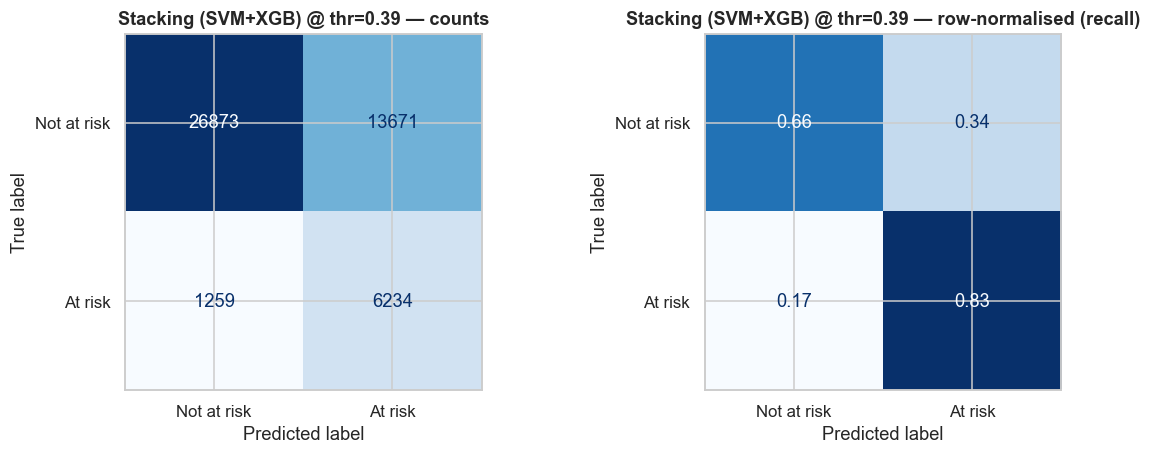

In [31]:
# Confusion matrix (counts + normalised) for the best model on TEST, at the TUNED
# threshold. We use from_predictions (not from_estimator) so the matrix reflects
# best_threshold rather than the library's hard-wired 0.50 cut-off.
pred_test = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title(f"{best_name} @ thr={best_threshold:.2f} — counts")
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[1], colorbar=False, normalize="true")
ax[1].set_title(f"{best_name} @ thr={best_threshold:.2f} — row-normalised (recall)")
plt.tight_layout(); plt.show()

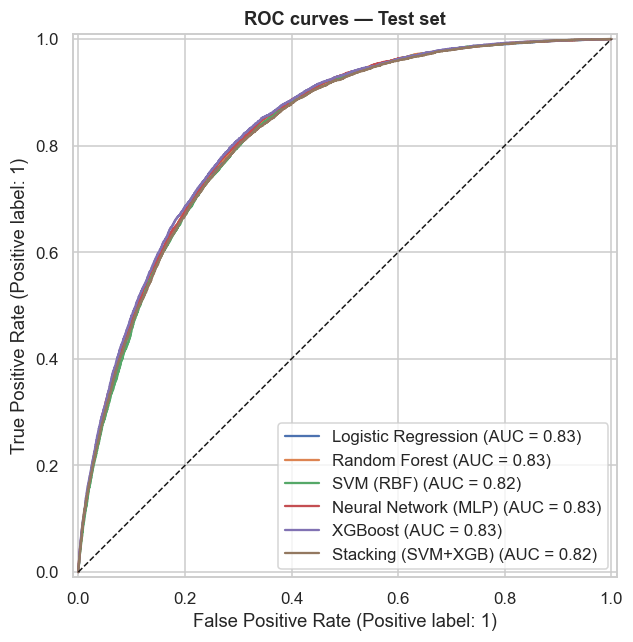

In [32]:
# ROC curves for every model on the TEST set
plt.figure(figsize=(7.5, 6))
ax = plt.gca()
for name, mdl in fitted.items():
    RocCurveDisplay.from_estimator(mdl, X_test, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.title("ROC curves — Test set"); plt.tight_layout(); plt.show()

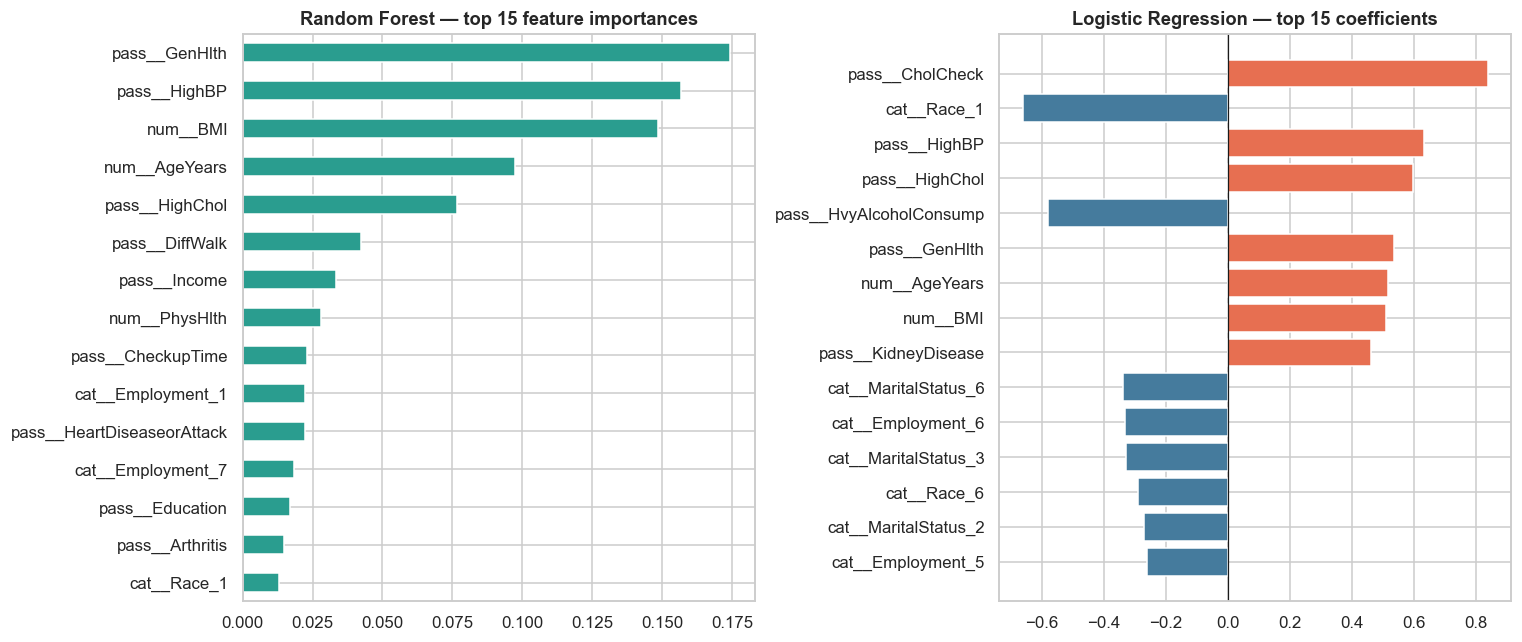

In [33]:
# What drives the prediction? Random Forest importances + Logistic Regression coefficients
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# RF importances
rf = fitted["Random Forest"]
feat_names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=feat_names).sort_values().tail(15)
imp.plot(kind="barh", ax=ax[0], color="#2A9D8F")
ax[0].set_title("Random Forest — top 15 feature importances")

# LR coefficients (odds-ratio direction)
lr = fitted["Logistic Regression"]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
coef = coef.reindex(coef.abs().sort_values().tail(15).index)
ax[1].barh(coef.index, coef.values, color=["#E76F51" if v > 0 else "#457B9D" for v in coef.values])
ax[1].set_title("Logistic Regression — top 15 coefficients"); ax[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

## 8 · Prediction on New Patients

The whole preprocessing + model pipeline is a single object, so scoring a brand-new
patient is one call. We feed raw feature values (same columns as `X`) and get a
calibrated **risk probability**.

In [34]:
# Two illustrative patients (must have the same columns as X, in any order)
def make_patient(**kw):
    base = X.median(numeric_only=True).to_dict()   # sensible defaults = population median
    base.update(kw)
    return pd.DataFrame([base])[X.columns]

high_risk = make_patient(BMI=38.5, AgeYears=68, HighBP=1, HighChol=1, GenHlth=5,
                         DiffWalk=1, HeartDiseaseorAttack=1, PhysActivity=0, Smoker=1)
low_risk  = make_patient(BMI=22.0, AgeYears=27, HighBP=0, HighChol=0, GenHlth=1,
                         DiffWalk=0, HeartDiseaseorAttack=0, PhysActivity=1, Smoker=0)

# We refer at the TUNED operating threshold (best_threshold from §6.6), not the
# arbitrary 0.50 -- this is the balanced point we actually deploy.
for label, p in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = best_model.predict_proba(p)[0, 1]
    verdict = "REFER for glucose test" if prob >= best_threshold else "routine monitoring"
    print(f"{label:20s} -> P(at risk) = {prob:5.1%}  (refer if >= {best_threshold:.0%})  =>  {verdict}")

High-risk profile    -> P(at risk) = 95.0%  (refer if >= 39%)  =>  REFER for glucose test
Low-risk profile     -> P(at risk) = 11.8%  (refer if >= 39%)  =>  routine monitoring


## 9 · Interactive Risk Calculator (Wow-factor)

An `ipywidgets` **in-depth questionnaire** exposing **all 29 model features** — the same risk
factors defined in the cleaning notebook (`01`), grouped into *body metrics, clinical history,
self-rated health, lifestyle, healthcare access* and *socio-economic* sections. Move any control
and the diabetes-risk score updates live; the referral decision uses the tuned recall-first
threshold from §6.6, not the arbitrary 0.50. *(Run this cell in Jupyter for the interactive version.)*

In [35]:
# ---------------------------------------------------------------------------
# In-depth interactive questionnaire: ALL 29 model features (same factors as
# notebook 01), grouped into clinical / lifestyle / demographic sections. Every
# control feeds the SAME preprocessing + stacking-ensemble pipeline; the referral decision
# uses the tuned recall-first threshold (best_threshold from Sec 6.6), not 0.50.
# ---------------------------------------------------------------------------
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Human-readable options for the coded features (encodings taken from notebook 01)
    YESNO   = [("No", 0), ("Yes", 1)]
    SEX     = [("Female", 0), ("Male", 1)]
    GENHLTH = [("1 - Excellent", 1), ("2 - Very good", 2), ("3 - Good", 3),
               ("4 - Fair", 4), ("5 - Poor", 5)]
    RACE    = [("White (non-Hisp.)", 1), ("Black (non-Hisp.)", 2), ("Amer. Indian / Alaska Native", 3),
               ("Asian", 4), ("Native Hawaiian / Pac. Isl.", 5), ("Other race", 6),
               ("Multiracial", 7), ("Hispanic", 8)]
    MARITAL = [("Married", 1), ("Divorced", 2), ("Widowed", 3), ("Separated", 4),
               ("Never married", 5), ("Unmarried couple", 6)]
    EDU     = [("Never attended", 1), ("Elementary", 2), ("Some high school", 3),
               ("High-school grad", 4), ("Some college / technical", 5), ("College grad", 6)]
    INCOME  = [("< $10k", 1), ("$10-15k", 2), ("$15-20k", 3), ("$20-25k", 4),
               ("$25-35k", 5), ("$35-50k", 6), ("$50-75k", 7), (">= $75k", 8)]
    EMPLOY  = [("Employed for wages", 1), ("Self-employed", 2), ("Out of work >= 1yr", 3),
               ("Out of work < 1yr", 4), ("Homemaker", 5), ("Student", 6),
               ("Retired", 7), ("Unable to work", 8)]
    CHECKUP = [("Within 1 year", 1), ("1-2 years", 2), ("2-5 years", 3),
               ("5+ years ago", 4), ("Never", 5)]

    _LBL = {"description_width": "initial"}
    _WDD = widgets.Layout(width="330px")
    _WSL = widgets.Layout(width="420px")

    def _dd(options, value, desc):
        return widgets.Dropdown(options=options, value=value, description=desc, style=_LBL, layout=_WDD)
    def _yn(value, desc):
        return _dd(YESNO, value, desc)

    # One widget per model feature (29 total)
    w = {
        # Body metrics
        "BMI":      widgets.FloatSlider(min=15, max=55, step=0.5, value=28, description="BMI", style=_LBL, layout=_WSL),
        "AgeYears": widgets.IntSlider(min=18, max=80, value=50, description="Age (years)", style=_LBL, layout=_WSL),
        "Sex":      _dd(SEX, 0, "Sex"),
        # Clinical history
        "HighBP":               _yn(0, "High blood pressure"),
        "HighChol":             _yn(0, "High cholesterol"),
        "CholCheck":            _yn(1, "Cholesterol checked (<5y)"),
        "Stroke":               _yn(0, "Stroke history"),
        "HeartDiseaseorAttack": _yn(0, "Heart disease / MI"),
        "KidneyDisease":        _yn(0, "Kidney disease"),
        "COPD":                 _yn(0, "COPD"),
        "Arthritis":            _yn(0, "Arthritis"),
        "Depression":           _yn(0, "Depression (ever told)"),
        "DiffWalk":             _yn(0, "Difficulty walking"),
        # Self-rated health
        "GenHlth":  _dd(GENHLTH, 3, "General health"),
        "MentHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor mental-health days / 30", style=_LBL, layout=_WSL),
        "PhysHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor physical-health days / 30", style=_LBL, layout=_WSL),
        # Lifestyle
        "Smoker":            _yn(0, "Smoked >= 100 cigarettes"),
        "PhysActivity":      _yn(1, "Physically active (30d)"),
        "Fruits":            _yn(1, "Fruit >= 1 / day"),
        "Veggies":           _yn(1, "Vegetables >= 1 / day"),
        "HvyAlcoholConsump": _yn(0, "Heavy alcohol use"),
        # Healthcare access
        "AnyHealthcare": _yn(1, "Has healthcare coverage"),
        "NoDocbcCost":   _yn(0, "Skipped doctor (cost)"),
        "CheckupTime":   _dd(CHECKUP, 1, "Last routine checkup"),
        # Socio-economic
        "Race":          _dd(RACE, 1, "Race / ethnicity"),
        "MaritalStatus": _dd(MARITAL, 1, "Marital status"),
        "Education":     _dd(EDU, 6, "Education"),
        "Income":        _dd(INCOME, 8, "Household income"),
        "Employment":    _dd(EMPLOY, 1, "Employment status"),
    }

    def _predict(**vals):
        patient = make_patient(**{k: (float(v) if k == "BMI" else int(v)) for k, v in vals.items()})
        prob = best_model.predict_proba(patient)[0, 1]
        band = ("HIGH RISK - refer for glucose test" if prob >= best_threshold
                else "Lower risk - routine monitoring")
        print(f"Predicted P(diabetes / pre-diabetes) : {prob:6.1%}")
        print(f"Referral threshold (recall-first)    : {best_threshold:5.0%}")
        print(f"Decision                             : {band}")

    out = widgets.interactive_output(_predict, w)

    def _section(title, keys):
        head = widgets.HTML(f"<b style='color:#264653;font-size:1.02em'>{title}</b>")
        return widgets.VBox([head] + [w[k] for k in keys],
                            layout=widgets.Layout(margin="0 24px 12px 0"))

    controls = widgets.VBox([
        _section("Body metrics",      ["BMI", "AgeYears", "Sex"]),
        _section("Clinical history",  ["HighBP", "HighChol", "CholCheck", "Stroke",
                                       "HeartDiseaseorAttack", "KidneyDisease", "COPD",
                                       "Arthritis", "Depression", "DiffWalk"]),
        _section("Self-rated health", ["GenHlth", "MentHlth", "PhysHlth"]),
        _section("Lifestyle",         ["Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump"]),
        _section("Healthcare access", ["AnyHealthcare", "NoDocbcCost", "CheckupTime"]),
        _section("Socio-economic",    ["Race", "MaritalStatus", "Education", "Income", "Employment"]),
    ])
    result = widgets.VBox([widgets.HTML("<b style='color:#264653;font-size:1.02em'>Live prediction</b>"), out])
    print("In-depth questionnaire - all 29 model features. Adjust any control for a live score:\n")
    display(widgets.HBox([controls, result]))
except Exception as e:
    print("Interactive widget needs a live Jupyter kernel. Error:", e)

In-depth questionnaire - all 29 model features. Adjust any control for a live score:



## 10 · Business Insights & Recommendations

* **A cheap questionnaire screens surprisingly well.** Using only self-reported survey
  answers (no blood test), the best model reaches a strong ROC-AUC — good enough to
  **triage** who should be sent for a confirmatory HbA1c/glucose test. This is exactly the
  kind of low-cost pre-screen a polyclinic or insurer can deploy.
* **Recall is the metric that matters here.** A missed at-risk patient (false negative)
  is far costlier than a false alarm. We tuned with `class_weight="balanced"`, which lifts
  recall on the minority class; the operating threshold can be lowered further to catch even
  more true cases at the cost of more referrals.
* **The top drivers are actionable:** high BMI, older age, high blood pressure, poor
  general health, and difficulty walking dominate both the RF importances and the LR
  coefficients — reinforcing **weight management and blood-pressure control** as the highest-
  leverage public-health interventions.
* **Emerging-tech opportunity:** the same pipeline could ingest wearable data (continuous
  glucose monitors, step counts) for real-time risk, and a GenAI layer could turn each
  prediction into a plain-language, personalised lifestyle recommendation.

**Responsible-AI caveat:** `Race` is predictive but socially sensitive; a deployed model
should be **audited for fairness** across ethnic groups (equal recall) and `Race` possibly
removed to avoid encoding structural inequities as clinical risk.

## 11 · Responsible Use of GenAI (Evidence & Reflection)

GenAI (an AI coding assistant) was used as a **pair-programmer**, with every suggestion
validated against scikit-learn docs and our own results.

| Where GenAI helped | Example prompt | Verdict |
|--------------------|----------------|---------|
| Feature justification | *"Which BRFSS 2015 variables are established risk factors for type-2 diabetes, and which would leak the target?"* | **Adopted** — flagged `INSULIN`, `DIABAGE2`, `BLDSUGAR` as leakage; we excluded them. |
| Leakage-safe pipeline | *"Show how to scale + one-hot encode inside a scikit-learn Pipeline so no test data leaks during CV."* | **Adopted** — `ColumnTransformer` inside `Pipeline` refits per fold. |
| Imbalance handling | *"My accuracy is 84% but recall on diabetics is poor — what should I do?"* | **Adopted** — `class_weight="balanced"` + judging on Recall/F1/AUC, not accuracy. |
| SVM runtime | *"RBF-SVM never finishes on 144k rows — options?"* | **Adopted with judgement** — used a stratified 15k subsample and documented the trade-off, rather than blindly switching kernels. |
| Hyperparameter grids | *"Suggest sensible grids for RF and MLP on tabular health data."* | **Adopted after pruning** — trimmed the suggested grid so `RandomizedSearchCV` runs in reasonable time. |
| Neural-net imbalance | *"How do I pass `class_weight='balanced'` to `MLPClassifier`?"* | **Rejected — the premise was wrong.** The assistant produced confident code for a parameter `MLPClassifier` simply does not have. We checked it against the scikit-learn API, then documented the gap in §5.4 and gave the network its sensitivity through the §6.5 threshold sweep instead. |

**Critical reflection / limitations of AI output:**
* Early AI drafts suggested plain `train_test_split` + fitting the scaler on all data —
  a **leakage bug** we caught and corrected by moving scaling inside the pipeline.
* An AI suggestion to "just use accuracy" was **rejected** — misleading on a 16%-positive
  imbalanced target.
* A hallucinated `MLPClassifier(class_weight="balanced")` was **caught against the API docs** —
  fluent AI code is not the same as correct AI code, so every unfamiliar argument was verified.
* GenAI cannot see our data, so all class-balance / correlation claims were **verified
  empirically** in the cells above before we trusted them.

*Every AI-assisted snippet was read, understood, and tested before inclusion — in line
with the module's academic-integrity requirements.*

## 12 · Model Export — Deployment Artifact

A model is only useful if it can leave the notebook. Because the deployed model is a **stacking
ensemble** (an SVM + XGBoost blend under a Logistic Regression meta-learner), the whole fitted
`Pipeline` — preprocessor **and** ensemble — is serialised together with **joblib**, scikit-learn's
recommended format for a fitted estimator. Keeping everything in one artifact means the exact
scaling, encoding and stacking evaluated in this notebook are applied at inference, with no chance
of a preprocessing mismatch in production.

We write two files to `../models/`:

| File | Format | Contains |
|------|--------|----------|
| `diabetes_stack_recall_first.joblib` | joblib (pickle) | the **whole** fitted pipeline — `StandardScaler` + `OneHotEncoder` + passthrough → `StackingClassifier(SVM + XGBoost → LogisticRegression)` |
| `diabetes_stack_recall_first.meta.json` | JSON sidecar | model name, **recall-first threshold** from §6.6, positive-class definition, feature order, library versions |

The sidecar travels with the artifact so the **feature order** and the **recall-first threshold**
can never silently drift from the notebook. The companion **clinic web app** (`clinic_app/`) loads
exactly these two files. The cell below saves the pair, reloads it in isolation (as a deployment
would), asserts it reproduces the notebook pipeline on the held-out test set, and scores the two
example patients from §8.

In [36]:
# --- 12a  Save the deployment artifact: the whole fitted pipeline + a metadata sidecar ---
import json, joblib, sklearn, xgboost as xgb
from pathlib import Path

EXPORT_DIR = Path("../models"); EXPORT_DIR.mkdir(exist_ok=True)
PIPE_PATH = EXPORT_DIR / "diabetes_stack_recall_first.joblib"
META_PATH = EXPORT_DIR / "diabetes_stack_recall_first.meta.json"

# best_model = Pipeline([("prep", ColumnTransformer), ("clf", StackingClassifier(...))]) from 6.6.
# joblib pickles the ENTIRE fitted object graph in one file, so the preprocessing, both base
# models and the meta-learner are restored together -- no need to split the pipeline apart.
joblib.dump(best_model, PIPE_PATH)

# A tiny sidecar records the deployment contract so it travels with the artifact.
META_PATH.write_text(json.dumps({
    "model":              best_name,
    "decision_threshold": round(float(best_threshold), 6),
    "positive_class":     "at_risk (pre-diabetes or diabetes)",
    "feature_order":      list(X.columns),
    "sklearn_version":    sklearn.__version__,
    "xgboost_version":    xgb.__version__,
}, indent=2))

print(f"Saved pipeline -> {PIPE_PATH.name}   ({PIPE_PATH.stat().st_size/1024:.0f} KB)")
print(f"Saved metadata -> {META_PATH.name}  "
      f"(threshold={best_threshold:.3f}, {X.shape[1]} features, "
      f"sklearn {sklearn.__version__}, xgboost {xgb.__version__})")

Saved pipeline -> diabetes_stack_recall_first.joblib   (5279 KB)
Saved metadata -> diabetes_stack_recall_first.meta.json  (threshold=0.390, 29 features, sklearn 1.7.2, xgboost 3.3.0)


In [37]:
# --- 12b  Reload the artifact in isolation and verify parity + score the section-8 patients ---
# Rebuild the model from the saved file only (a fresh object, exactly as the clinic app does),
# then confirm it reproduces the notebook pipeline on the held-out TEST set.
reloaded = joblib.load(PIPE_PATH)
reloaded_meta = json.loads(META_PATH.read_text())
reload_threshold = float(reloaded_meta["decision_threshold"])

reloaded_proba = reloaded.predict_proba(X_test)[:, 1]
notebook_proba = best_model.predict_proba(X_test)[:, 1]

max_diff  = float(np.abs(reloaded_proba - notebook_proba).max())
agreement = float(((reloaded_proba >= reload_threshold) == (notebook_proba >= reload_threshold)).mean())
print("joblib reload vs in-notebook pipeline -- parity on the held-out TEST set")
print(f"  probability |diff| : max {max_diff:.2e}   (pickle round-trips the exact fitted objects)")
print(f"  refer/monitor decision agreement @ threshold {reload_threshold:.2f}: {agreement:.3%}")

# joblib restores the identical Python objects, so we demand bit-exact parity.
assert max_diff < 1e-9, "joblib reload does not reproduce the notebook pipeline -- investigate before deploying."
assert agreement == 1.0, "joblib reload flips a decision vs the notebook -- investigate."
print("\nPASS - the exported artifact reproduces the deployed pipeline exactly.")

# Score the two section-8 example patients through the reloaded artifact only.
print(f"\nScoring via the reloaded artifact only (refer if P >= {reload_threshold:.0%}):\n")
for label, patient in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = float(reloaded.predict_proba(patient)[0, 1])
    verdict = "REFER for glucose test" if prob >= reload_threshold else "routine monitoring"
    print(f"  {label:20s} -> P(at risk) = {prob:5.1%}  =>  {verdict}")

print(f"\nDeployment recipe: joblib.load('{PIPE_PATH.name}'), read the threshold from "
      f"'{META_PATH.name}',\nthen refer when predict_proba(patient)[:, 1] >= threshold.")

joblib reload vs in-notebook pipeline -- parity on the held-out TEST set
  probability |diff| : max 0.00e+00   (pickle round-trips the exact fitted objects)
  refer/monitor decision agreement @ threshold 0.39: 100.000%

PASS - the exported artifact reproduces the deployed pipeline exactly.

Scoring via the reloaded artifact only (refer if P >= 39%):

  High-risk profile    -> P(at risk) = 95.0%  =>  REFER for glucose test
  Low-risk profile     -> P(at risk) = 11.8%  =>  routine monitoring

Deployment recipe: joblib.load('diabetes_stack_recall_first.joblib'), read the threshold from 'diabetes_stack_recall_first.meta.json',
then refer when predict_proba(patient)[:, 1] >= threshold.


### 12.1 · What goes in the submission

After running §12, `../models/` holds the deployable artifacts to include in the
**Project Zip** (alongside the two notebooks, `requirements.txt`, the slides and the
signed AI Integrity Declaration Form):

| File | Role |
|------|------|
| `diabetes_stack_recall_first.joblib` | the whole fitted pipeline — preprocessor → SVM+XGBoost stacking ensemble (§12) |
| `diabetes_stack_recall_first.meta.json` | model name, recall-first threshold, feature order, library versions (§12) |

Both carry the **recall-first operating threshold**, so whoever deploys the model reproduces the
exact refer / monitor behaviour analysed in §7 — this is precisely what the companion
`clinic_app/` loads. The dataset itself is submitted separately as the **Dataset Zip** per the
assignment brief.